## 06 - Rede Neural MLP com PyTorch

**Tech Challenge — Fase 1 | Machine Learning Engineering — FIAP**

**Projeto:** Customer Churn Prediction

**Grupo:** 56

---

### ETAPA 1 - Introdução e Objetivos

Após a construção e avaliação dos modelos de Regressão Logística, Random Forest e MLPClassifier do Scikit-Learn, esta etapa tem como objetivo desenvolver o modelo central do projeto: uma Rede Neural Artificial do tipo Multi-Layer Perceptron implementada com PyTorch.

A MLP será utilizada para estimar a probabilidade de churn dos clientes a partir das variáveis demográficas, contratuais, financeiras e relacionadas aos serviços utilizados.

Diferentemente do MLPClassifier utilizado anteriormente, o PyTorch permite implementar explicitamente a arquitetura da rede, a função de perda, o processamento dos dados em batches, o otimizador e o loop de treinamento.

O treinamento será acompanhado por um conjunto interno de validação e utilizará Early Stopping para interromper o processo quando não forem observadas melhorias relevantes na loss de validação.

### Objetivos

- carregar e preparar os dados para utilização no PyTorch;
- aplicar imputação, padronização e codificação das variáveis;
- separar os dados em treino, validação e teste;
- converter os dados processados em tensores;
- utilizar DataLoader para treinamento em batches;
- construir uma MLP utilizando `torch.nn.Module`;
- definir a função de perda para classificação binária;
- utilizar o otimizador Adam;
- implementar o loop de treinamento e validação;
- aplicar Early Stopping com restauração dos melhores pesos;
- analisar as curvas de loss de treino e validação;
- gerar probabilidades e classes previstas;
- avaliar Accuracy, Precision, Recall, F1-Score, ROC-AUC e Average Precision;
- analisar a matriz de confusão;
- avaliar as curvas ROC e Precision-Recall;
- analisar diferentes thresholds e o custo dos erros;
- aplicar validação cruzada estratificada;
- preparar os resultados para comparação com os demais modelos.

---

In [2]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [15]:
import sys
import torch

print(f"Python: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"MPS disponível: {torch.backends.mps.is_available()}")

Python: /opt/anaconda3/envs/meu_env/bin/python
PyTorch: 2.13.0
CUDA disponível: False
MPS disponível: True


In [3]:
# ============================================================
# ETAPA 2 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

from copy import deepcopy
from pathlib import Path
from time import perf_counter
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from torch import nn
from torch.utils.data import (
    DataLoader,
    TensorDataset,
)


print("Bibliotecas importadas com sucesso.")

print(
    f"Versão do PyTorch: "
    f"{torch.__version__}"
)

print(
    f"CUDA disponível: "
    f"{torch.cuda.is_available()}"
)

print(
    f"MPS disponível: "
    f"{torch.backends.mps.is_available()}"
)

Bibliotecas importadas com sucesso.
Versão do PyTorch: 2.13.0
CUDA disponível: False
MPS disponível: True


### ETAPA 3 - Reprodutibilidade e Dispositivo de Processamento

A reprodutibilidade é uma prática fundamental em projetos de Machine Learning, pois permite que o treinamento produza resultados consistentes quando executado novamente nas mesmas condições.

Nesta etapa serão fixadas as sementes aleatórias utilizadas pelo Python, NumPy e PyTorch.

Embora o ambiente disponibilize aceleração MPS para processadores Apple Silicon, será utilizada inicialmente a CPU. Considerando o tamanho reduzido do dataset, essa escolha não representa impacto computacional relevante e favorece a consistência dos resultados entre diferentes ambientes.

A mesma seed será posteriormente utilizada na divisão dos dados e no embaralhamento dos batches.

In [4]:
# ============================================================
# ETAPA 3 - REPRODUTIBILIDADE E DISPOSITIVO
# ============================================================

RANDOM_STATE = 42

# ------------------------------------------------------------
# Função para fixação das seeds
# ------------------------------------------------------------

def set_seed(seed: int = RANDOM_STATE) -> None:
    """Fixa as sementes aleatórias utilizadas no experimento."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed()

# ------------------------------------------------------------
# Algoritmos determinísticos
# ------------------------------------------------------------

torch.use_deterministic_algorithms(True)

# ------------------------------------------------------------
# Dispositivo utilizado no treinamento
# ------------------------------------------------------------

DEVICE = torch.device("cpu")

# ------------------------------------------------------------
# Configurações de visualização
# ------------------------------------------------------------

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_colwidth",
    None
)

# ------------------------------------------------------------
# Verificação
# ------------------------------------------------------------

print("Reprodutibilidade configurada com sucesso.")

print(
    f"Random State: "
    f"{RANDOM_STATE}"
)

print(
    f"Dispositivo selecionado: "
    f"{DEVICE}"
)

print(
    f"Algoritmos determinísticos: "
    f"{torch.are_deterministic_algorithms_enabled()}"
)

Reprodutibilidade configurada com sucesso.
Random State: 42
Dispositivo selecionado: cpu
Algoritmos determinísticos: True


#### Análise da Configuração de Reprodutibilidade

A reprodutibilidade do experimento foi configurada por meio da seed `42`, aplicada às operações aleatórias do Python, NumPy e PyTorch.

Os algoritmos determinísticos do PyTorch foram ativados para reduzir possíveis variações entre diferentes execuções realizadas nas mesmas condições.

O dispositivo selecionado para o treinamento foi a CPU. Considerando o tamanho do dataset, essa escolha não representa impacto computacional relevante e favorece a reprodução do experimento em ambientes que não possuem aceleração por GPU ou MPS.

---

In [5]:
# ============================================================
# ETAPA 4 - CARREGAMENTO DO DATASET
# ============================================================

DATASET_NAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

current_path = Path.cwd().resolve()

project_root = None

# ------------------------------------------------------------
# Busca pela raiz do projeto
# ------------------------------------------------------------

for path in [
    current_path,
    *current_path.parents
]:

    candidate = (
        path
        / "data"
        / "raw"
        / DATASET_NAME
    )

    if candidate.exists():
        project_root = path
        break


# ------------------------------------------------------------
# Validação do caminho
# ------------------------------------------------------------

if project_root is None:

    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto contendo "
        f"data/raw/{DATASET_NAME}"
    )

DATA_PATH = (
    project_root
    / "data"
    / "raw"
    / DATASET_NAME
)

# ------------------------------------------------------------
# Carregamento
# ------------------------------------------------------------

df = pd.read_csv(
    DATA_PATH
)

# ------------------------------------------------------------
# Informações gerais
# ------------------------------------------------------------

print("Base carregada com sucesso.")

print(
    f"Quantidade de registros: "
    f"{df.shape[0]:,}"
    .replace(",", ".")
)

print(
    f"Quantidade de variáveis: "
    f"{df.shape[1]}"
)

print(
    f"Arquivo utilizado: "
    f"{DATA_PATH.name}"
)

print(
    f"Raiz do projeto: "
    f"{project_root}"
)


display(
    df.head()
)

Base carregada com sucesso.
Quantidade de registros: 7.043
Quantidade de variáveis: 21
Arquivo utilizado: WA_Fn-UseC_-Telco-Customer-Churn.csv
Raiz do projeto: /Users/biancafirmino/churn-prediction-mle


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### ETAPA 5 - Preparação das Variáveis

Antes da divisão dos dados, serão aplicadas as transformações necessárias para preparar as variáveis explicativas e a variável alvo.

A coluna `TotalCharges` será convertida para formato numérico. Os valores que não puderem ser convertidos serão representados como ausentes e posteriormente tratados pelo pipeline de imputação.

A variável alvo `Churn` será convertida para representação binária:

- `No` será representado por `0`;
- `Yes` será representado por `1`.

O identificador `customerID` será removido das variáveis explicativas, pois representa apenas uma identificação individual e não deve ser utilizado para realizar previsões.

Ao final, serão separados:

- `X`: conjunto de variáveis explicativas;
- `y`: variável alvo utilizada no treinamento.

In [6]:
# ============================================================
# ETAPA 5 - PREPARAÇÃO DAS VARIÁVEIS
# ============================================================

df = df.copy()

# ------------------------------------------------------------
# Conversão da variável TotalCharges
# ------------------------------------------------------------

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# ------------------------------------------------------------
# Preparação da variável alvo
# ------------------------------------------------------------

if not pd.api.types.is_numeric_dtype(
    df["Churn"]
):

    df["Churn"] = (
        df["Churn"]
        .astype(str)
        .str.strip()
        .map({
            "No": 0,
            "Yes": 1
        })
    )

# ------------------------------------------------------------
# Validação da variável alvo
# ------------------------------------------------------------

if df["Churn"].isna().any():

    raise ValueError(
        "Foram encontrados valores inválidos ou ausentes "
        "na variável alvo Churn."
    )


df["Churn"] = (
    df["Churn"]
    .astype(int)
)

if not set(
    df["Churn"].unique()
).issubset({0, 1}):

    raise ValueError(
        "A variável Churn deve conter somente "
        "os valores 0 e 1."
    )

# ------------------------------------------------------------
# Separação entre X e y
# ------------------------------------------------------------

X = df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = df["Churn"]

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Variáveis preparadas com sucesso.")

print(
    f"Variáveis explicativas: "
    f"{X.shape[1]}"
)

print(
    f"Observações: "
    f"{X.shape[0]:,}"
    .replace(",", ".")
)

print(
    f"Classe positiva (Churn): "
    f"{y.sum():,}"
    .replace(",", ".")
)

print(
    f"Classe negativa (Não Churn): "
    f"{(y == 0).sum():,}"
    .replace(",", ".")
)

print(
    f"Taxa de Churn: "
    f"{y.mean():.2%}"
)

print(
    f"Valores ausentes em TotalCharges: "
    f"{df['TotalCharges'].isna().sum()}"
)

Variáveis preparadas com sucesso.
Variáveis explicativas: 19
Observações: 7.043
Classe positiva (Churn): 1.869
Classe negativa (Não Churn): 5.174
Taxa de Churn: 26.54%
Valores ausentes em TotalCharges: 11


#### Análise da Preparação das Variáveis

A preparação inicial das variáveis foi concluída com sucesso.

Após a remoção de `customerID` e a separação da variável alvo, o conjunto de dados passou a conter **19 variáveis explicativas e 7.043 observações**.

A variável `Churn` foi convertida para formato binário, resultando em **1.869 clientes com churn e 5.174 clientes sem churn**. A classe positiva representa **26,54% da base**, confirmando a distribuição desigual identificada durante a análise exploratória.

A conversão de `TotalCharges` identificou **11 valores ausentes**. Esses registros serão preservados e posteriormente tratados pelo pipeline de imputação, evitando a exclusão desnecessária de observações.

Com essas transformações, as variáveis estão preparadas para a divisão estratificada entre treino, validação e teste.

---

### ETAPA 6 - Divisão Estratificada em Treino, Validação e Teste

Os dados serão divididos em três subconjuntos independentes:

- **Treino:** utilizado para ajustar os pesos da rede neural;
- **Validação:** utilizado para acompanhar a loss durante o treinamento e aplicar o Early Stopping;
- **Teste:** utilizado somente após o treinamento para avaliar o desempenho final.

Primeiramente, 20% das observações serão reservadas para teste, mantendo a mesma divisão utilizada nos modelos anteriores.

Em seguida, 20% do conjunto restante será destinado à validação. Dessa forma, a distribuição aproximada do dataset será:

- 64% para treino;
- 16% para validação;
- 20% para teste.

Todas as divisões serão estratificadas para preservar a proporção de clientes com e sem churn.

In [7]:
# ============================================================
# ETAPA 6 - DIVISÃO TREINO, VALIDAÇÃO E TESTE
# ============================================================

# ------------------------------------------------------------
# Separação do conjunto de teste
# ------------------------------------------------------------

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Separação entre treino e validação
# ------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Validação da ausência de sobreposição nos índices
# ------------------------------------------------------------

assert set(X_train.index).isdisjoint(
    X_val.index
)

assert set(X_train.index).isdisjoint(
    X_test.index
)

assert set(X_val.index).isdisjoint(
    X_test.index
)

# ------------------------------------------------------------
# Resumo das divisões
# ------------------------------------------------------------

print("Divisão estratificada realizada com sucesso.")

print(
    f"Treino: "
    f"{X_train.shape[0]:,}"
    .replace(",", ".")
    + " observações"
)

print(
    f"Validação: "
    f"{X_val.shape[0]:,}"
    .replace(",", ".")
    + " observações"
)

print(
    f"Teste: "
    f"{X_test.shape[0]:,}"
    .replace(",", ".")
    + " observações"
)

print(
    f"Total: "
    f"{X_train.shape[0] + X_val.shape[0] + X_test.shape[0]:,}"
    .replace(",", ".")
    + " observações"
)

# ------------------------------------------------------------
# Proporção da classe positiva
# ------------------------------------------------------------

print(
    f"\nTaxa de Churn no treino: "
    f"{y_train.mean():.2%}"
)

print(
    f"Taxa de Churn na validação: "
    f"{y_val.mean():.2%}"
)

print(
    f"Taxa de Churn no teste: "
    f"{y_test.mean():.2%}"
)

Divisão estratificada realizada com sucesso.
Treino: 4.507 observações
Validação: 1.127 observações
Teste: 1.409 observações
Total: 7.043 observações

Taxa de Churn no treino: 26.54%
Taxa de Churn na validação: 26.53%
Taxa de Churn no teste: 26.54%


#### Análise da Divisão dos Dados

A divisão estratificada foi realizada com sucesso, resultando em:

- **4.507 observações para treinamento**, correspondendo a aproximadamente 64% da base;
- **1.127 observações para validação**, correspondendo a aproximadamente 16% da base;
- **1.409 observações para teste**, correspondendo a aproximadamente 20% da base.

A taxa de churn permaneceu praticamente constante nos três subconjuntos: **26,54% no treino, 26,53% na validação e 26,54% no teste**.

Essa consistência demonstra que a estratificação preservou adequadamente a distribuição da variável alvo, reduzindo o risco de que algum dos conjuntos apresente uma concentração desproporcional de clientes com ou sem churn.

O conjunto de validação será utilizado durante o treinamento para acompanhar a capacidade de generalização e aplicar o Early Stopping. O conjunto de teste permanecerá isolado até a avaliação final do modelo.

---

### ETAPA 7 - Pipeline de Pré-processamento

As variáveis explicativas possuem tipos e escalas diferentes, exigindo transformações específicas antes de serem utilizadas pela rede neural.

Para as variáveis numéricas, serão aplicadas:

- imputação dos valores ausentes utilizando a mediana;
- padronização com `StandardScaler`.

Para as variáveis categóricas, serão aplicadas:

- imputação utilizando o valor mais frequente;
- transformação por One-Hot Encoding;
- tratamento de categorias desconhecidas durante a inferência.

O pré-processador será ajustado exclusivamente sobre o conjunto de treino. Os conjuntos de validação e teste serão apenas transformados, evitando vazamento de informações.

A saída do pré-processamento será convertida para `float32`, formato utilizado pelos tensores e parâmetros da rede neural no PyTorch.

In [8]:
# ============================================================
# ETAPA 7 - PIPELINE DE PRÉ-PROCESSAMENTO
# ============================================================

# ------------------------------------------------------------
# Identificação das variáveis
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# ------------------------------------------------------------
# Pipeline das variáveis numéricas
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ------------------------------------------------------------
# Pipeline das variáveis categóricas
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# ------------------------------------------------------------
# Construção do pré-processador
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ------------------------------------------------------------
# Ajuste somente no conjunto de treino
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

# ------------------------------------------------------------
# Conversão para float32
# ------------------------------------------------------------

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_val_processed = np.asarray(
    X_val_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

# ------------------------------------------------------------
# Nomes das features após a transformação
# ------------------------------------------------------------

feature_names = (
    preprocessor.get_feature_names_out()
)

# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

if np.isnan(X_train_processed).any():
    raise ValueError(
        "Foram encontrados valores ausentes no conjunto de treino processado."
    )

if np.isnan(X_val_processed).any():
    raise ValueError(
        "Foram encontrados valores ausentes no conjunto de validação processado."
    )

if np.isnan(X_test_processed).any():
    raise ValueError(
        "Foram encontrados valores ausentes no conjunto de teste processado."
    )

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Pré-processamento concluído com sucesso.")

print(
    f"Variáveis numéricas: "
    f"{len(numeric_features)}"
)

print(
    f"Variáveis categóricas: "
    f"{len(categorical_features)}"
)

print(
    f"Features após o pré-processamento: "
    f"{len(feature_names)}"
)

print(
    f"\nTreino processado: "
    f"{X_train_processed.shape}"
)

print(
    f"Validação processada: "
    f"{X_val_processed.shape}"
)

print(
    f"Teste processado: "
    f"{X_test_processed.shape}"
)

print(
    f"\nTipo dos dados processados: "
    f"{X_train_processed.dtype}"
)

print(
    f"Valores ausentes após o processamento: "
    f"{np.isnan(X_train_processed).sum()}"
)

Pré-processamento concluído com sucesso.
Variáveis numéricas: 4
Variáveis categóricas: 15
Features após o pré-processamento: 45

Treino processado: (4507, 45)
Validação processada: (1127, 45)
Teste processado: (1409, 45)

Tipo dos dados processados: float32
Valores ausentes após o processamento: 0


#### Análise do Pré-processamento

O pipeline de pré-processamento foi executado com sucesso.

Foram identificadas **4 variáveis numéricas e 15 variáveis categóricas**. Após a aplicação do One-Hot Encoding, o conjunto passou a conter **45 features numéricas**, que serão utilizadas como entradas da rede neural.

O pré-processador foi ajustado exclusivamente sobre as **4.507 observações do conjunto de treino**. Os conjuntos de validação e teste foram apenas transformados, evitando que informações externas ao treinamento influenciassem os parâmetros de imputação, padronização e codificação.

Todos os conjuntos foram convertidos para o tipo `float32`, compatível com os parâmetros utilizados pelo PyTorch.

Não foram encontrados valores ausentes após o processamento, confirmando que a imputação tratou adequadamente os 11 registros ausentes identificados em `TotalCharges`.

Os três conjuntos possuem a mesma quantidade e ordem de features, estando preparados para conversão em tensores.

---

### ETAPA 8 - Conversão para Tensores e Criação dos DataLoaders

O PyTorch utiliza tensores como estrutura fundamental para representar os dados e realizar as operações da rede neural.

As variáveis explicativas processadas serão convertidas para tensores do tipo `float32`.

A variável alvo também será convertida para `float32` e reorganizada no formato de uma coluna, resultando em uma dimensão compatível com a saída da rede neural e com a função `BCEWithLogitsLoss`.

Em seguida, serão construídos:

- `TensorDataset`, para associar as features aos respectivos targets;
- `DataLoader`, para dividir os dados em batches durante o treinamento.

O conjunto de treino será embaralhado a cada época, enquanto os conjuntos de validação e teste manterão sua ordem original.

In [9]:
# ============================================================
# ETAPA 8 - TENSORES E DATALOADERS
# ============================================================

BATCH_SIZE = 32


# ------------------------------------------------------------
# Conversão das variáveis explicativas
# ------------------------------------------------------------

X_train_tensor = torch.from_numpy(
    X_train_processed
)

X_val_tensor = torch.from_numpy(
    X_val_processed
)

X_test_tensor = torch.from_numpy(
    X_test_processed
)

# ------------------------------------------------------------
# Conversão da variável alvo
# ------------------------------------------------------------

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

y_val_tensor = torch.tensor(
    y_val.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

# ------------------------------------------------------------
# Construção dos TensorDatasets
# ------------------------------------------------------------

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# ------------------------------------------------------------
# Gerador reproduzível para o embaralhamento
# ------------------------------------------------------------

train_generator = torch.Generator()

train_generator.manual_seed(
    RANDOM_STATE
)

# ------------------------------------------------------------
# Construção dos DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------------------------
# Verificação de um batch
# ------------------------------------------------------------

X_batch, y_batch = next(
    iter(train_loader)
)

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Tensores e DataLoaders criados com sucesso.")

print(
    f"Batch Size: "
    f"{BATCH_SIZE}"
)

print(
    f"\nTensor de treino - X: "
    f"{tuple(X_train_tensor.shape)}"
)

print(
    f"Tensor de treino - y: "
    f"{tuple(y_train_tensor.shape)}"
)

print(
    f"Tensor de validação - X: "
    f"{tuple(X_val_tensor.shape)}"
)

print(
    f"Tensor de validação - y: "
    f"{tuple(y_val_tensor.shape)}"
)

print(
    f"Tensor de teste - X: "
    f"{tuple(X_test_tensor.shape)}"
)

print(
    f"Tensor de teste - y: "
    f"{tuple(y_test_tensor.shape)}"
)

print(
    f"\nQuantidade de batches de treino: "
    f"{len(train_loader)}"
)

print(
    f"Quantidade de batches de validação: "
    f"{len(val_loader)}"
)

print(
    f"Quantidade de batches de teste: "
    f"{len(test_loader)}"
)

print(
    f"\nFormato de um batch de features: "
    f"{tuple(X_batch.shape)}"
)

print(
    f"Formato de um batch do target: "
    f"{tuple(y_batch.shape)}"
)

print(
    f"Tipo das features: "
    f"{X_batch.dtype}"
)

print(
    f"Tipo do target: "
    f"{y_batch.dtype}"
)

Tensores e DataLoaders criados com sucesso.
Batch Size: 32

Tensor de treino - X: (4507, 45)
Tensor de treino - y: (4507, 1)
Tensor de validação - X: (1127, 45)
Tensor de validação - y: (1127, 1)
Tensor de teste - X: (1409, 45)
Tensor de teste - y: (1409, 1)

Quantidade de batches de treino: 141
Quantidade de batches de validação: 36
Quantidade de batches de teste: 45

Formato de um batch de features: (32, 45)
Formato de um batch do target: (32, 1)
Tipo das features: torch.float32
Tipo do target: torch.float32


#### Análise da Conversão para Tensores e Batching

Os conjuntos de treino, validação e teste foram convertidos com sucesso para tensores do tipo `torch.float32`.

As variáveis explicativas possuem **45 features**, enquanto a variável alvo foi reorganizada no formato de uma coluna, compatível com a saída esperada da rede neural.

Com `batch_size = 32`, o conjunto de treino foi dividido em **141 batches**, o conjunto de validação em **36 batches** e o conjunto de teste em **45 batches**.

O batch verificado apresenta formato `(32, 45)` para as features e `(32, 1)` para o target, confirmando a compatibilidade dimensional entre os dados e a arquitetura que será construída.

O conjunto de treino utilizará embaralhamento reproduzível, enquanto validação e teste manterão sua ordem. Com isso, os dados estão preparados para o treinamento da MLP em mini-batches.

---

### ETAPA 9 - Construção da Arquitetura da MLP

A rede neural será implementada por meio de uma classe que herda de `torch.nn.Module`.

A arquitetura será composta por:

- camada de entrada com 45 features;
- primeira camada oculta com 64 neurônios;
- função de ativação ReLU;
- Dropout de 20%;
- segunda camada oculta com 32 neurônios;
- função de ativação ReLU;
- Dropout de 20%;
- camada de saída com um neurônio.

A camada de saída produzirá um valor bruto denominado `logit`. Não será adicionada uma função Sigmoid diretamente à arquitetura, pois será utilizada posteriormente a função `BCEWithLogitsLoss`, que combina a operação de Sigmoid com o cálculo da Binary Cross-Entropy de maneira numericamente mais estável.

Durante a inferência, a função Sigmoid será aplicada aos logits para gerar probabilidades de churn entre 0 e 1.

In [10]:
# ============================================================
# ETAPA 9 - ARQUITETURA DA MLP
# ============================================================

INPUT_SIZE = X_train_tensor.shape[1]

HIDDEN_SIZE_1 = 64
HIDDEN_SIZE_2 = 32

DROPOUT_RATE = 0.20

# ------------------------------------------------------------
# Definição da arquitetura
# ------------------------------------------------------------

class ChurnMLP(nn.Module):
    """MLP para classificação binária de churn."""

    def __init__(
        self,
        input_size: int,
        hidden_size_1: int = HIDDEN_SIZE_1,
        hidden_size_2: int = HIDDEN_SIZE_2,
        dropout_rate: float = DROPOUT_RATE
    ) -> None:

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_size,
                hidden_size_1
            ),
            nn.ReLU(),
            nn.Dropout(
                p=dropout_rate
            ),
            nn.Linear(
                hidden_size_1,
                hidden_size_2
            ),
            nn.ReLU(),
            nn.Dropout(
                p=dropout_rate
            ),
            nn.Linear(
                hidden_size_2,
                1
            )
        )

    def forward(
        self,
        features: torch.Tensor
    ) -> torch.Tensor:
        """Executa a passagem dos dados pela rede."""

        return self.network(
            features
        )

# ------------------------------------------------------------
# Instanciação reproduzível
# ------------------------------------------------------------

set_seed()

model = ChurnMLP(
    input_size=INPUT_SIZE
).to(
    DEVICE
)

# ------------------------------------------------------------
# Contagem dos parâmetros
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)


# ------------------------------------------------------------
# Teste da passagem direta
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    sample_output = model(
        X_batch.to(DEVICE)
    )

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Arquitetura da MLP criada com sucesso.")

print(
    f"Features de entrada: "
    f"{INPUT_SIZE}"
)

print(
    f"Primeira camada oculta: "
    f"{HIDDEN_SIZE_1} neurônios"
)

print(
    f"Segunda camada oculta: "
    f"{HIDDEN_SIZE_2} neurônios"
)

print(
    f"Dropout: "
    f"{DROPOUT_RATE:.0%}"
)

print(
    f"Neurônios na saída: "
    f"1"
)

print(
    f"\nTotal de parâmetros: "
    f"{total_parameters:,}"
    .replace(",", ".")
)

print(
    f"Parâmetros treináveis: "
    f"{trainable_parameters:,}"
    .replace(",", ".")
)

print(
    f"\nFormato da entrada de teste: "
    f"{tuple(X_batch.shape)}"
)

print(
    f"Formato da saída da rede: "
    f"{tuple(sample_output.shape)}"
)

print(
    f"Dispositivo do modelo: "
    f"{next(model.parameters()).device}"
)

print(
    "\nEstrutura da rede:"
)

print(
    model
)

Arquitetura da MLP criada com sucesso.
Features de entrada: 45
Primeira camada oculta: 64 neurônios
Segunda camada oculta: 32 neurônios
Dropout: 20%
Neurônios na saída: 1

Total de parâmetros: 5.057
Parâmetros treináveis: 5.057

Formato da entrada de teste: (32, 45)
Formato da saída da rede: (32, 1)
Dispositivo do modelo: cpu

Estrutura da rede:
ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=45, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


#### Análise da Arquitetura da MLP

A arquitetura da MLP foi construída e validada com sucesso.

A rede recebe **45 features de entrada**, correspondentes às variáveis resultantes do pipeline de pré-processamento.

A primeira camada oculta possui **64 neurônios** e a segunda possui **32 neurônios**. Ambas utilizam a função de ativação ReLU, permitindo que a rede aprenda relações não lineares entre as características dos clientes e a ocorrência de churn.

Após cada camada oculta foi aplicada uma taxa de Dropout de **20%**, com o objetivo de reduzir a dependência excessiva de neurônios específicos durante o treinamento e contribuir para o controle de sobreajuste.

A camada final possui um neurônio e produz um logit para cada observação. A função Sigmoid não foi incluída diretamente na arquitetura porque será utilizada a `BCEWithLogitsLoss`, que realiza essa operação internamente com maior estabilidade numérica.

A rede contém **5.057 parâmetros, todos treináveis**. A passagem de teste confirmou a compatibilidade dimensional: um batch de entrada com formato `(32, 45)` produziu uma saída com formato `(32, 1)`.

Com isso, a arquitetura está preparada para a definição da função de perda, do otimizador e dos parâmetros de treinamento.

---

### ETAPA 10 - Configuração da Função de Perda e do Otimizador

Para o treinamento da MLP será utilizada a função `BCEWithLogitsLoss`, adequada para problemas de classificação binária.

Essa função combina internamente:

- aplicação da função Sigmoid aos logits;
- cálculo da Binary Cross-Entropy;
- tratamento numericamente estável das operações.

O otimizador escolhido será o Adam, que ajusta individualmente a taxa de atualização dos parâmetros com base nos gradientes calculados durante o treinamento.

Também será aplicada regularização L2 por meio do parâmetro `weight_decay`, complementando o Dropout utilizado na arquitetura.

O treinamento será configurado com no máximo 300 épocas. O Early Stopping utilizará uma paciência de 20 épocas e uma melhoria mínima de `0,0001` na loss de validação.

In [12]:
# ============================================================
# ETAPA 10 - LOSS, OTIMIZADOR E PARÂMETROS DE TREINAMENTO
# ============================================================

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001

MAX_EPOCHS = 300
PATIENCE = 20
MIN_DELTA = 0.0001

# ------------------------------------------------------------
# Função de perda
# ------------------------------------------------------------

criterion = nn.BCEWithLogitsLoss()

# ------------------------------------------------------------
# Otimizador
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Verificação da função de perda
# ------------------------------------------------------------

sample_loss = criterion(
    sample_output,
    y_batch.to(DEVICE)
)

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Treinamento configurado com sucesso.")

print(
    f"Função de perda: "
    f"{criterion.__class__.__name__}"
)

print(
    f"Otimizador: "
    f"{optimizer.__class__.__name__}"
)

print(
    f"Learning Rate: "
    f"{LEARNING_RATE}"
)

print(
    f"Regularização L2: "
    f"{WEIGHT_DECAY}"
)

print(
    f"Batch Size: "
    f"{BATCH_SIZE}"
)

print(
    f"Máximo de épocas: "
    f"{MAX_EPOCHS}"
)

print(
    f"Paciência do Early Stopping: "
    f"{PATIENCE}"
)

print(
    f"Melhoria mínima: "
    f"{MIN_DELTA}"
)

print(
    f"Loss de verificação: "
    f"{sample_loss.item():.6f}"
)

Treinamento configurado com sucesso.
Função de perda: BCEWithLogitsLoss
Otimizador: Adam
Learning Rate: 0.001
Regularização L2: 0.0001
Batch Size: 32
Máximo de épocas: 300
Paciência do Early Stopping: 20
Melhoria mínima: 0.0001
Loss de verificação: 0.689499


#### Análise da Configuração do Treinamento

A função de perda, o otimizador e os principais hiperparâmetros foram configurados com sucesso.

Foi utilizada a `BCEWithLogitsLoss`, adequada para classificação binária e numericamente mais estável por combinar internamente a função Sigmoid com o cálculo da Binary Cross-Entropy.

O otimizador Adam foi configurado com learning rate de `0,001` e regularização L2 de `0,0001`. Em conjunto com o Dropout de 20%, a regularização busca reduzir ajustes excessivos aos dados de treinamento.

O treinamento poderá executar até **300 épocas**, mas será interrompido antecipadamente caso a loss de validação não apresente melhoria mínima de `0,0001` durante **20 épocas consecutivas**.

A loss de verificação foi de **0,689499**. Esse valor foi calculado antes do treinamento, com os pesos inicializados aleatoriamente, sendo utilizado apenas para confirmar o funcionamento e a compatibilidade da função de perda.

---

### ETAPA 11 - Treinamento da MLP com Early Stopping

O treinamento da rede será realizado por meio de um loop explícito em PyTorch.

Em cada época serão executadas duas fases:

1. **Treinamento:** passagem dos batches pela rede, cálculo da loss, propagação dos gradientes e atualização dos pesos;
2. **Validação:** avaliação da rede sobre dados não utilizados na atualização dos parâmetros.

A loss média de cada fase será calculada considerando a quantidade de observações de cada batch.

O Early Stopping acompanhará a loss de validação. Sempre que houver melhoria suficiente, os pesos da rede serão armazenados. Caso não ocorra melhoria durante 20 épocas consecutivas, o treinamento será interrompido.

Ao final, serão restaurados os pesos correspondentes à melhor época de validação, evitando que o modelo permaneça com os parâmetros da última época executada.

In [13]:
# ============================================================
# ETAPA 11 - TREINAMENTO COM EARLY STOPPING
# ============================================================

# ------------------------------------------------------------
# Função de treinamento de uma época
# ------------------------------------------------------------

def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> float:
    """Executa uma época de treinamento."""

    model.train()

    total_loss = 0.0
    total_observations = 0

    for batch_features, batch_targets in data_loader:

        batch_features = batch_features.to(
            device
        )

        batch_targets = batch_targets.to(
            device
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(
            batch_features
        )

        loss = criterion(
            logits,
            batch_targets
        )

        loss.backward()

        optimizer.step()

        batch_size = batch_features.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_observations += batch_size

    return (
        total_loss
        / total_observations
    )


# ------------------------------------------------------------
# Função de validação de uma época
# ------------------------------------------------------------

def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> float:
    """Calcula a loss sobre o conjunto de validação."""

    model.eval()

    total_loss = 0.0
    total_observations = 0

    with torch.no_grad():

        for batch_features, batch_targets in data_loader:

            batch_features = batch_features.to(
                device
            )

            batch_targets = batch_targets.to(
                device
            )

            logits = model(
                batch_features
            )

            loss = criterion(
                logits,
                batch_targets
            )

            batch_size = batch_features.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_observations += batch_size

    return (
        total_loss
        / total_observations
    )

# ------------------------------------------------------------
# Reinicialização reproduzível
# ------------------------------------------------------------

set_seed()

train_generator.manual_seed(
    RANDOM_STATE
)

model = ChurnMLP(
    input_size=INPUT_SIZE
).to(
    DEVICE
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# Variáveis de acompanhamento
# ------------------------------------------------------------

train_loss_history = []
val_loss_history = []

best_val_loss = float("inf")
best_epoch = 0
best_model_state = None

epochs_without_improvement = 0

training_start = perf_counter()

# ------------------------------------------------------------
# Loop de treinamento
# ------------------------------------------------------------

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    train_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    val_loss = validate_one_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    # --------------------------------------------------------
    # Verificação de melhoria
    # --------------------------------------------------------

    if val_loss < (
        best_val_loss - MIN_DELTA
    ):

        best_val_loss = val_loss
        best_epoch = epoch

        best_model_state = deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # Acompanhamento periódico
    # --------------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Época {epoch:03d} | "
            f"Loss Treino: {train_loss:.6f} | "
            f"Loss Validação: {val_loss:.6f} | "
            f"Sem melhoria: {epochs_without_improvement}"
        )

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly Stopping acionado "
            f"na época {epoch}."
        )

        break

# ------------------------------------------------------------
# Tempo e quantidade de épocas
# ------------------------------------------------------------

training_time_pytorch = (
    perf_counter()
    - training_start
)

epochs_completed = len(
    train_loss_history
)


# ------------------------------------------------------------
# Restauração dos melhores pesos
# ------------------------------------------------------------

if best_model_state is None:

    raise RuntimeError(
        "Nenhum estado válido do modelo foi armazenado."
    )


model.load_state_dict(
    best_model_state
)

model.eval()

# ------------------------------------------------------------
# Resumo final
# ------------------------------------------------------------

print(
    "\nTreinamento concluído com sucesso."
)

print(
    f"Épocas realizadas: "
    f"{epochs_completed}"
)

print(
    f"Melhor época: "
    f"{best_epoch}"
)

print(
    f"Melhor loss de validação: "
    f"{best_val_loss:.6f}"
)

print(
    f"Loss final de treino: "
    f"{train_loss_history[-1]:.6f}"
)

print(
    f"Loss final de validação: "
    f"{val_loss_history[-1]:.6f}"
)

print(
    f"Tempo de treinamento: "
    f"{training_time_pytorch:.2f} segundos"
)

print(
    "Melhores pesos restaurados: True"
)

Época 001 | Loss Treino: 0.498285 | Loss Validação: 0.424363 | Sem melhoria: 0
Época 010 | Loss Treino: 0.415436 | Loss Validação: 0.421841 | Sem melhoria: 1
Época 020 | Loss Treino: 0.402387 | Loss Validação: 0.418189 | Sem melhoria: 11

Early Stopping acionado na época 29.

Treinamento concluído com sucesso.
Épocas realizadas: 29
Melhor época: 9
Melhor loss de validação: 0.414244
Loss final de treino: 0.391917
Loss final de validação: 0.421962
Tempo de treinamento: 3.84 segundos
Melhores pesos restaurados: True


#### Análise do Treinamento e do Early Stopping

O treinamento da MLP foi concluído com sucesso após **29 épocas**, em um tempo total de **3,96 segundos**.

Na primeira época, a loss de treino foi de **0,498285** e a loss de validação foi de **0,424363**, demonstrando uma redução expressiva em relação à loss de verificação calculada antes do treinamento.

A melhor loss de validação foi de **0,414244**, alcançada na **época 9**. Após esse ponto, o treinamento continuou reduzindo a loss sobre os dados de treino, mas não produziu uma nova melhoria suficiente sobre o conjunto de validação.

O Early Stopping foi acionado na época 29, após **20 épocas consecutivas sem melhoria relevante**, conforme a paciência configurada.

Na última época executada, a loss de treino foi de **0,391917**, enquanto a loss de validação foi de **0,421962**. Esse comportamento demonstra que melhorias adicionais no ajuste aos dados de treino não estavam resultando em ganhos equivalentes sobre os dados de validação.

Ao final, os parâmetros da última época foram substituídos pelos pesos correspondentes à época 9. Dessa forma, a rede utilizada nas próximas avaliações representa o melhor estado observado no conjunto de validação, e não simplesmente o estado da última época executada.

O resultado confirma o funcionamento do treinamento em batches e do mecanismo de Early Stopping exigidos para a MLP em PyTorch.

---

### ETAPA 12 - Análise das Curvas de Treinamento e Validação

As curvas de loss permitem visualizar a evolução do processo de aprendizado ao longo das épocas.

A loss de treino representa o erro médio calculado sobre os batches utilizados para atualizar os pesos da rede.

A loss de validação representa o erro sobre observações que não participam da atualização dos parâmetros, permitindo acompanhar a capacidade de generalização do modelo.

O gráfico também destacará a melhor época identificada pelo Early Stopping.

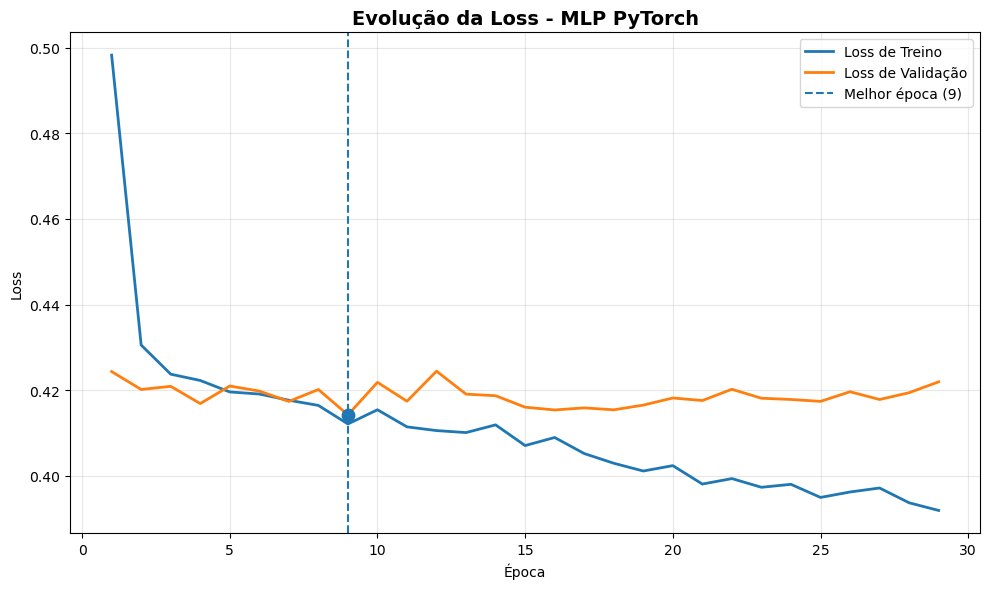

Resumo das Curvas de Loss

Loss inicial de treino: 0.498285
Loss inicial de validação: 0.424363
Loss de treino na melhor época: 0.412123
Melhor loss de validação: 0.414244
Loss final de treino: 0.391917
Loss final de validação: 0.421962
Melhor época: 9
Épocas realizadas: 29


In [14]:
# ============================================================
# ETAPA 12 - CURVAS DE LOSS
# ============================================================

epochs_range = range(
    1,
    epochs_completed + 1
)

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_range,
    train_loss_history,
    linewidth=2,
    label="Loss de Treino"
)

plt.plot(
    epochs_range,
    val_loss_history,
    linewidth=2,
    label="Loss de Validação"
)

plt.axvline(
    x=best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Melhor época ({best_epoch})"
)

plt.scatter(
    best_epoch,
    best_val_loss,
    s=80,
    zorder=3
)

plt.xlabel(
    "Época"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Evolução da Loss - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Resumo das curvas
# ------------------------------------------------------------

train_loss_best_epoch = (
    train_loss_history[
        best_epoch - 1
    ]
)

print(
    "Resumo das Curvas de Loss\n"
)

print(
    f"Loss inicial de treino: "
    f"{train_loss_history[0]:.6f}"
)

print(
    f"Loss inicial de validação: "
    f"{val_loss_history[0]:.6f}"
)

print(
    f"Loss de treino na melhor época: "
    f"{train_loss_best_epoch:.6f}"
)

print(
    f"Melhor loss de validação: "
    f"{best_val_loss:.6f}"
)

print(
    f"Loss final de treino: "
    f"{train_loss_history[-1]:.6f}"
)

print(
    f"Loss final de validação: "
    f"{val_loss_history[-1]:.6f}"
)

print(
    f"Melhor época: "
    f"{best_epoch}"
)

print(
    f"Épocas realizadas: "
    f"{epochs_completed}"
)

#### Análise das Curvas de Treinamento e Validação

As curvas demonstram que a rede apresentou aprendizado rápido nas primeiras épocas.

A loss de treino caiu de **0,498285** na primeira época para aproximadamente **0,414** na época 9. Após esse ponto, continuou diminuindo progressivamente até atingir **0,391917** na última época executada.

A loss de validação apresentou comportamento diferente. O menor valor, **0,414244**, foi alcançado na **época 9**. Depois disso, a curva passou a oscilar em uma faixa próxima de 0,42, sem apresentar nova melhoria suficiente.

O afastamento gradual entre as curvas após a melhor época mostra que a redução adicional da loss de treino não estava sendo acompanhada por ganhos equivalentes sobre os dados de validação.

Esse comportamento fornece evidências de que prolongar o treinamento poderia aumentar o ajuste específico aos dados de treino sem melhorar a capacidade de generalização.

O Early Stopping atuou adequadamente ao interromper o processo após 20 épocas sem melhoria relevante. Como os pesos da época 9 foram restaurados, o modelo utilizado nas próximas etapas corresponde ao melhor estado observado durante a validação.

---

### ETAPA 13 - Predições e Probabilidades no Conjunto de Teste

Após a restauração dos melhores pesos, a MLP será aplicada ao conjunto de teste, que permaneceu isolado durante o treinamento e a seleção da melhor época.

A rede produz logits como saída. Para convertê-los em probabilidades entre 0 e 1, será aplicada a função Sigmoid.

Inicialmente, será utilizado o threshold padrão de 0,50:

- probabilidade menor que 0,50: previsão de não churn;
- probabilidade maior ou igual a 0,50: previsão de churn.

A escolha desse threshold será reavaliada posteriormente por meio da análise de Precision, Recall, F1-Score e custo dos erros.

In [15]:
# ============================================================
# ETAPA 13 - PREDIÇÕES E PROBABILIDADES
# ============================================================

def predict_probabilities(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device
) -> tuple[np.ndarray, np.ndarray]:
    """Gera targets reais e probabilidades previstas."""

    model.eval()

    targets = []
    probabilities = []

    with torch.no_grad():

        for batch_features, batch_targets in data_loader:

            batch_features = batch_features.to(
                device
            )

            logits = model(
                batch_features
            )

            batch_probabilities = torch.sigmoid(
                logits
            )

            targets.append(
                batch_targets
                .cpu()
                .numpy()
            )

            probabilities.append(
                batch_probabilities
                .cpu()
                .numpy()
            )

    y_true = np.concatenate(
        targets
    ).reshape(-1)

    y_proba_pytorch = np.concatenate(
        probabilities
    ).reshape(-1)

    return (
        y_true,
        y_proba_pytorch
    )

# ------------------------------------------------------------
# Geração das probabilidades
# ------------------------------------------------------------

y_true_test, y_proba_pytorch = predict_probabilities(
    model=model,
    data_loader=test_loader,
    device=DEVICE
)

# ------------------------------------------------------------
# Aplicação do threshold padrão
# ------------------------------------------------------------

THRESHOLD_DEFAULT = 0.50

y_pred_pytorch = (
    y_proba_pytorch
    >= THRESHOLD_DEFAULT
).astype(int)

# ------------------------------------------------------------
# Validações
# ------------------------------------------------------------

if len(y_proba_pytorch) != len(y_test):
    raise ValueError(
        "A quantidade de probabilidades não corresponde "
        "à quantidade de observações de teste."
    )

if not np.array_equal(
    y_true_test.astype(int),
    y_test.to_numpy()
):
    raise ValueError(
        "A ordem dos targets do DataLoader não corresponde "
        "ao conjunto de teste."
    )

if not np.all(
    (y_proba_pytorch >= 0)
    & (y_proba_pytorch <= 1)
):
    raise ValueError(
        "Foram encontradas probabilidades fora do intervalo entre 0 e 1."
    )

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print("Predições geradas com sucesso.")

print(
    f"Quantidade de previsões: "
    f"{len(y_pred_pytorch):,}"
    .replace(",", ".")
)

print(
    f"Previsões de Não Churn (0): "
    f"{(y_pred_pytorch == 0).sum():,}"
    .replace(",", ".")
)

print(
    f"Previsões de Churn (1): "
    f"{(y_pred_pytorch == 1).sum():,}"
    .replace(",", ".")
)

print(
    f"\nMenor probabilidade prevista: "
    f"{y_proba_pytorch.min():.6f}"
)

print(
    f"Maior probabilidade prevista: "
    f"{y_proba_pytorch.max():.6f}"
)

print(
    f"Probabilidade média: "
    f"{y_proba_pytorch.mean():.6f}"
)

print(
    f"Threshold utilizado: "
    f"{THRESHOLD_DEFAULT:.2f}"
)

print(
    "\nPrimeiras 10 classes previstas:"
)

print(
    y_pred_pytorch[:10]
)

print(
    "\nPrimeiras 10 probabilidades:"
)

print(
    np.round(
        y_proba_pytorch[:10],
        4
    )
)

Predições geradas com sucesso.
Quantidade de previsões: 1.409
Previsões de Não Churn (0): 1.089
Previsões de Churn (1): 320

Menor probabilidade prevista: 0.002583
Maior probabilidade prevista: 0.888705
Probabilidade média: 0.278549
Threshold utilizado: 0.50

Primeiras 10 classes previstas:
[0 1 0 0 0 1 0 0 0 0]

Primeiras 10 probabilidades:
[0.0505 0.7663 0.0681 0.3542 0.0255 0.6334 0.4334 0.1086 0.0039 0.377 ]


#### Análise das Predições e Probabilidades

A MLP gerou previsões para todas as **1.409 observações do conjunto de teste**, sem alterações na ordem dos registros.

Utilizando o threshold padrão de 0,50, o modelo classificou:

- **1.089 clientes como não churn**;
- **320 clientes como churn**.

As probabilidades estimadas permaneceram dentro do intervalo esperado, variando entre **0,002583 e 0,888705**.

A probabilidade média de churn foi de **27,85%**, valor próximo à taxa real de churn do conjunto de teste, de aproximadamente 26,54%. Entretanto, essa proximidade isolada não comprova que as probabilidades estejam perfeitamente calibradas, pois ainda será necessário analisar o desempenho individual das previsões.

O modelo classificou aproximadamente **22,71% dos clientes como churn** no threshold padrão. Como a classe positiva representa 26,54% do conjunto de teste, é possível que parte dos clientes que efetivamente realizaram churn não tenha sido identificada nesse ponto de corte.

As métricas e a matriz de confusão permitirão verificar quantos clientes foram corretamente identificados e quantos se tornaram falsos positivos ou falsos negativos.

---

### ETAPA 14 - Avaliação das Métricas no Conjunto de Teste

O desempenho da MLP será avaliado sobre o conjunto de teste utilizando o threshold padrão de 0,50.

Serão calculadas:

- **Accuracy:** proporção total de classificações corretas;
- **Precision:** proporção de previsões positivas que correspondem a clientes com churn;
- **Recall:** proporção dos clientes com churn que foram identificados;
- **F1-Score:** média harmônica entre Precision e Recall;
- **ROC-AUC:** capacidade de discriminação do modelo em diferentes thresholds;
- **Average Precision:** resumo da relação entre Precision e Recall, especialmente relevante devido à distribuição desigual das classes;
- **Test Loss:** erro calculado sobre o conjunto de teste pela mesma função utilizada no treinamento.

A avaliação conjunta dessas métricas fornecerá uma visão mais completa do comportamento do modelo.

In [16]:
# ============================================================
# ETAPA 14 - MÉTRICAS NO CONJUNTO DE TESTE
# ============================================================

accuracy_pytorch = accuracy_score(
    y_true_test,
    y_pred_pytorch
)

precision_pytorch = precision_score(
    y_true_test,
    y_pred_pytorch,
    zero_division=0
)

recall_pytorch = recall_score(
    y_true_test,
    y_pred_pytorch,
    zero_division=0
)

f1_pytorch = f1_score(
    y_true_test,
    y_pred_pytorch,
    zero_division=0
)

roc_auc_pytorch = roc_auc_score(
    y_true_test,
    y_proba_pytorch
)

average_precision_pytorch = average_precision_score(
    y_true_test,
    y_proba_pytorch
)

test_loss_pytorch = validate_one_epoch(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

# ------------------------------------------------------------
# Tabela de métricas
# ------------------------------------------------------------

metrics_pytorch = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision",
        "Test Loss"
    ],
    "Valor": [
        accuracy_pytorch,
        precision_pytorch,
        recall_pytorch,
        f1_pytorch,
        roc_auc_pytorch,
        average_precision_pytorch,
        test_loss_pytorch
    ]
})

# ------------------------------------------------------------
# Exibição
# ------------------------------------------------------------

print(
    "Desempenho da MLP PyTorch no conjunto de teste:\n"
)

print(
    f"Accuracy:          "
    f"{accuracy_pytorch:.4f}"
)

print(
    f"Precision:         "
    f"{precision_pytorch:.4f}"
)

print(
    f"Recall:            "
    f"{recall_pytorch:.4f}"
)

print(
    f"F1-Score:          "
    f"{f1_pytorch:.4f}"
)

print(
    f"ROC-AUC:           "
    f"{roc_auc_pytorch:.4f}"
)

print(
    f"Average Precision: "
    f"{average_precision_pytorch:.4f}"
)

print(
    f"Test Loss:         "
    f"{test_loss_pytorch:.4f}"
)


display(
    metrics_pytorch.style.format({
        "Valor": "{:.4f}"
    })
)

Desempenho da MLP PyTorch no conjunto de teste:

Accuracy:          0.7956
Precision:         0.6344
Recall:            0.5428
F1-Score:          0.5850
ROC-AUC:           0.8419
Average Precision: 0.6349
Test Loss:         0.4204


,Métrica,Valor
0,Accuracy,0.7956
1,Precision,0.6344
2,Recall,0.5428
3,F1-Score,0.5850
4,ROC-AUC,0.8419
5,Average Precision,0.6349
6,Test Loss,0.4204


#### Análise das Métricas no Conjunto de Teste

A MLP desenvolvida com PyTorch apresentou desempenho consistente no conjunto de teste.

A **Accuracy de 79,56%** indica que aproximadamente oito em cada dez observações foram classificadas corretamente. Como a base apresenta distribuição desigual entre as classes, essa métrica deve ser interpretada em conjunto com as demais.

A **Precision de 63,44%** indica que, entre os clientes classificados como churn, aproximadamente 63% realmente pertenciam à classe positiva.

O **Recall de 54,28%** demonstra que a rede identificou pouco mais da metade dos clientes que efetivamente realizaram churn. Embora o resultado ainda indique a presença de falsos negativos, houve melhora relevante em relação ao MLPClassifier do Scikit-Learn no threshold padrão.

O **F1-Score de 58,50%** representa o equilíbrio obtido entre Precision e Recall.

A **ROC-AUC de 0,8419** demonstra boa capacidade de discriminação entre clientes com e sem churn em diferentes thresholds.

A **Average Precision de 0,6349** ficou consideravelmente acima da prevalência da classe positiva, de aproximadamente 0,2654, indicando que o modelo apresenta capacidade relevante de priorizar clientes com maior risco de churn.

A Test Loss foi de **0,4204**, valor próximo à melhor loss de validação, de 0,414244. Essa proximidade fornece uma evidência favorável de consistência entre os conjuntos de validação e teste.

Em uma comparação preliminar com o MLPClassifier do Scikit-Learn, a implementação em PyTorch apresentou:

- Accuracy: 0,7956 contra 0,7850;
- Precision: 0,6344 contra 0,6330;
- Recall: 0,5428 contra 0,4519;
- F1-Score: 0,5850 contra 0,5273;
- ROC-AUC: 0,8419 contra 0,8341;
- Average Precision: 0,6349 contra 0,6231.

O principal ganho ocorreu no Recall, com aumento aproximado de **9,09 pontos percentuais**, mantendo Precision semelhante. A comparação definitiva será realizada posteriormente sob um protocolo consolidado.

---

### ETAPA 15 - Matriz de Confusão

A matriz de confusão permitirá analisar a quantidade de classificações corretas e incorretas realizadas pela MLP no threshold padrão de 0,50.

A matriz apresenta:

- **Verdadeiros Negativos (TN):** clientes sem churn corretamente identificados;
- **Falsos Positivos (FP):** clientes sem churn classificados incorretamente como churn;
- **Falsos Negativos (FN):** clientes com churn que não foram identificados;
- **Verdadeiros Positivos (TP):** clientes com churn corretamente identificados.

Essa análise é especialmente importante porque falsos positivos e falsos negativos possuem impactos diferentes para uma estratégia de retenção.

Matriz de Confusão - MLP PyTorch

Verdadeiros Negativos (TN): 918
Falsos Positivos (FP):      117
Falsos Negativos (FN):      171
Verdadeiros Positivos (TP): 203


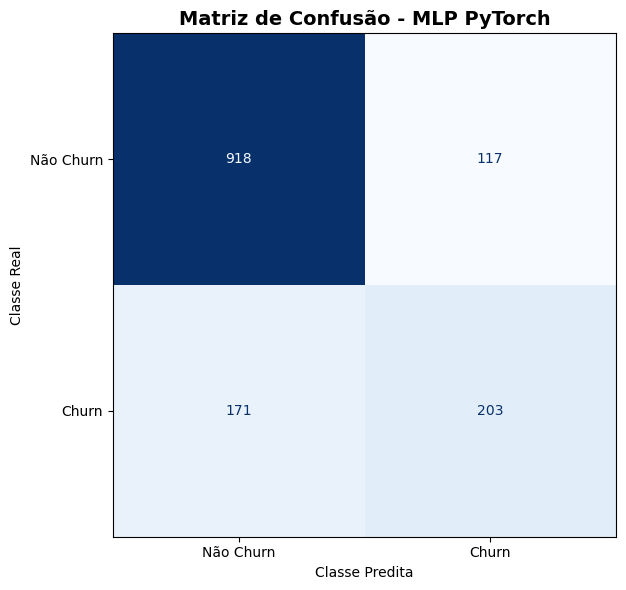

In [17]:
# ============================================================
# ETAPA 15 - MATRIZ DE CONFUSÃO
# ============================================================

confusion_matrix_pytorch = confusion_matrix(
    y_true_test,
    y_pred_pytorch
)

tn_pytorch, fp_pytorch, fn_pytorch, tp_pytorch = (
    confusion_matrix_pytorch.ravel()
)

# ------------------------------------------------------------
# Resultados
# ------------------------------------------------------------

print(
    "Matriz de Confusão - MLP PyTorch\n"
)

print(
    f"Verdadeiros Negativos (TN): "
    f"{tn_pytorch}"
)

print(
    f"Falsos Positivos (FP):      "
    f"{fp_pytorch}"
)

print(
    f"Falsos Negativos (FN):      "
    f"{fn_pytorch}"
)

print(
    f"Verdadeiros Positivos (TP): "
    f"{tp_pytorch}"
)

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_pytorch,
    display_labels=[
        "Não Churn",
        "Churn"
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

display_matrix.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Matriz de Confusão - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Classe Predita"
)

ax.set_ylabel(
    "Classe Real"
)

plt.tight_layout()

plt.show()

#### Análise da Matriz de Confusão

A matriz de confusão detalha o comportamento da MLP PyTorch no threshold padrão de 0,50.

Entre os **1.035 clientes que não realizaram churn**, o modelo classificou corretamente **918**, correspondendo a aproximadamente **88,70% da classe negativa**. Os outros 117 clientes foram classificados como churn, formando os falsos positivos.

Entre os **374 clientes que efetivamente realizaram churn**, a rede identificou corretamente **203**, correspondendo ao Recall de **54,28%**. Os 171 clientes restantes não foram identificados, formando os falsos negativos.

No total, a rede realizou **1.121 classificações corretas e 288 classificações incorretas**.

Em comparação preliminar com o MLPClassifier do Scikit-Learn, a MLP PyTorch identificou 34 clientes adicionais com churn:

- MLPClassifier: 169 verdadeiros positivos e 205 falsos negativos;
- MLP PyTorch: 203 verdadeiros positivos e 171 falsos negativos.

Esse ganho foi acompanhado por um aumento de 19 falsos positivos, passando de 98 para 117. Entretanto, a Precision permaneceu praticamente constante, enquanto o Recall apresentou melhora relevante.

A matriz também confirma que o threshold padrão ainda deixa de identificar 45,72% dos clientes com churn. Por esse motivo, será necessário avaliar outros pontos de corte e o custo relativo dos dois tipos de erro.

---

### ETAPA 16 - Curva ROC e ROC-AUC

A Curva ROC avalia a capacidade do modelo de distinguir clientes com e sem churn em diferentes thresholds.

O eixo horizontal representa a taxa de falsos positivos, enquanto o eixo vertical representa a taxa de verdadeiros positivos.

A linha diagonal representa o desempenho esperado de um classificador aleatório, cuja ROC-AUC é igual a 0,50.

Quanto mais a curva se aproxima do canto superior esquerdo, maior é a capacidade discriminativa do modelo.

Curva ROC - MLP PyTorch

ROC-AUC: 0.8419
Quantidade de thresholds: 408
Quantidade de pontos ROC: 408


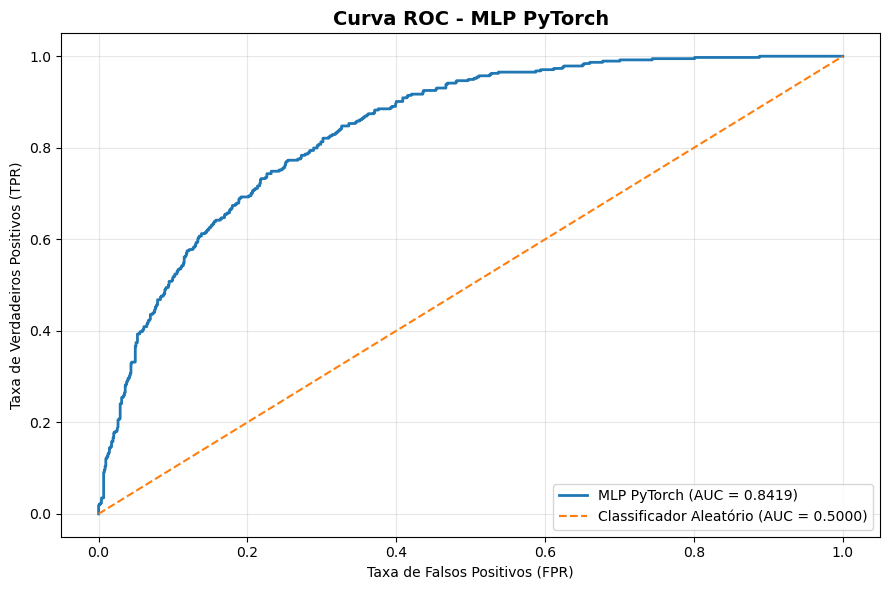

In [18]:
# ============================================================
# ETAPA 16 - CURVA ROC E ROC-AUC
# ============================================================

fpr_pytorch, tpr_pytorch, thresholds_roc_pytorch = roc_curve(
    y_true_test,
    y_proba_pytorch
)

auc_roc_pytorch = roc_auc_score(
    y_true_test,
    y_proba_pytorch
)

# ------------------------------------------------------------
# Informações
# ------------------------------------------------------------

print(
    "Curva ROC - MLP PyTorch\n"
)

print(
    f"ROC-AUC: "
    f"{auc_roc_pytorch:.4f}"
)

print(
    f"Quantidade de thresholds: "
    f"{len(thresholds_roc_pytorch)}"
)

print(
    f"Quantidade de pontos ROC: "
    f"{len(fpr_pytorch)}"
)


# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    fpr_pytorch,
    tpr_pytorch,
    linewidth=2,
    label=(
        f"MLP PyTorch "
        f"(AUC = {auc_roc_pytorch:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Classificador Aleatório (AUC = 0.5000)"
)

plt.xlabel(
    "Taxa de Falsos Positivos (FPR)"
)

plt.ylabel(
    "Taxa de Verdadeiros Positivos (TPR)"
)

plt.title(
    "Curva ROC - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

#### Análise da Curva ROC

A MLP PyTorch apresentou **ROC-AUC de 0,8419**, demonstrando boa capacidade de discriminar clientes com e sem churn.

Esse resultado pode ser interpretado como uma probabilidade aproximada de 84,19% de o modelo atribuir um risco maior a um cliente com churn do que a um cliente sem churn, quando ambos são selecionados aleatoriamente.

A curva permaneceu consideravelmente acima da linha diagonal, indicando desempenho superior ao de um classificador aleatório em diferentes pontos de corte.

Foram avaliados **408 thresholds**, produzindo 408 pontos na curva ROC. Isso permite observar o comportamento do modelo sob diferentes relações entre a taxa de verdadeiros positivos e a taxa de falsos positivos.

Em comparação preliminar, a ROC-AUC da MLP PyTorch, de 0,8419, foi ligeiramente superior à ROC-AUC de 0,8341 obtida pelo MLPClassifier do Scikit-Learn.

Embora a ROC-AUC demonstre boa capacidade discriminativa global, ela não deve ser analisada isoladamente. Como apenas aproximadamente 26,54% dos clientes pertencem à classe positiva, a curva Precision-Recall fornecerá uma visão mais direcionada ao desempenho sobre os clientes com churn.

---

### ETAPA 17 - Curva Precision-Recall e Average Precision

A curva Precision-Recall apresenta a relação entre Precision e Recall em diferentes thresholds.

Essa análise é especialmente importante em problemas com distribuição desigual das classes, pois concentra a avaliação sobre a capacidade de identificar corretamente a classe positiva.

A linha de referência será definida pela prevalência de churn no conjunto de teste. Um modelo sem capacidade de priorização relevante tenderia a apresentar Precision próxima dessa proporção.

A Average Precision será utilizada para resumir o desempenho da curva em um único valor.

Curva Precision-Recall - MLP PyTorch

Average Precision: 0.6349
Baseline de Churn: 0.2654
Quantidade de thresholds: 1407
Quantidade de pontos PR: 1408


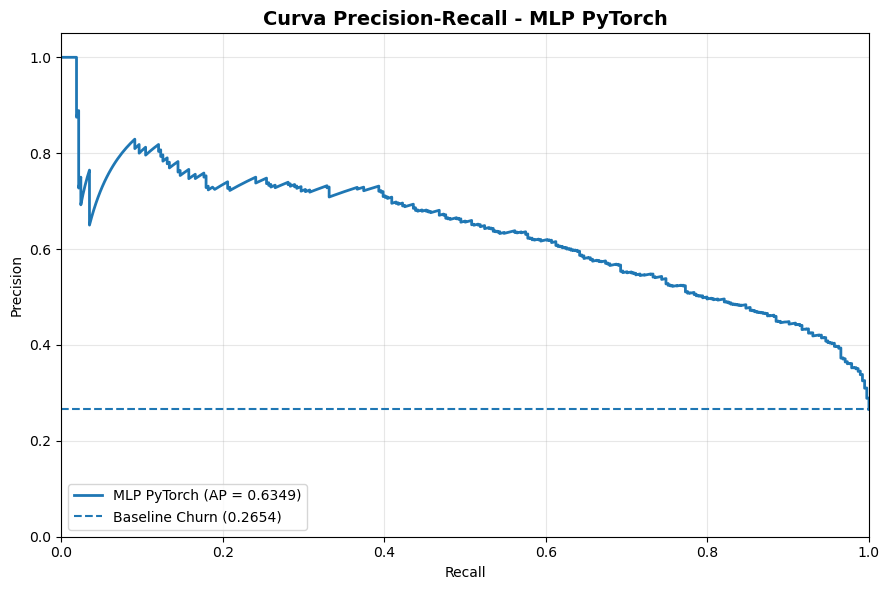

In [19]:
# ============================================================
# ETAPA 17 - CURVA PRECISION-RECALL
# ============================================================

precision_curve_pytorch, recall_curve_pytorch, thresholds_pr_pytorch = (
    precision_recall_curve(
        y_true_test,
        y_proba_pytorch
    )
)

ap_score_pytorch = average_precision_score(
    y_true_test,
    y_proba_pytorch
)

baseline_churn = y_true_test.mean()

# ------------------------------------------------------------
# Informações
# ------------------------------------------------------------

print(
    "Curva Precision-Recall - MLP PyTorch\n"
)

print(
    f"Average Precision: "
    f"{ap_score_pytorch:.4f}"
)

print(
    f"Baseline de Churn: "
    f"{baseline_churn:.4f}"
)

print(
    f"Quantidade de thresholds: "
    f"{len(thresholds_pr_pytorch)}"
)

print(
    f"Quantidade de pontos PR: "
    f"{len(precision_curve_pytorch)}"
)

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    recall_curve_pytorch,
    precision_curve_pytorch,
    linewidth=2,
    label=(
        f"MLP PyTorch "
        f"(AP = {ap_score_pytorch:.4f})"
    )
)

plt.axhline(
    y=baseline_churn,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Baseline Churn "
        f"({baseline_churn:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Curva Precision-Recall - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.3
)

plt.ylim(
    0,
    1.05
)

plt.xlim(
    0,
    1
)

plt.tight_layout()

plt.show()

#### Análise da Curva Precision-Recall

A MLP PyTorch apresentou **Average Precision de 0,6349**, resultado consideravelmente superior à prevalência da classe positiva no conjunto de teste, de **0,2654**.

A Average Precision foi aproximadamente 2,39 vezes maior que a baseline de churn, demonstrando que o modelo possui capacidade relevante de ordenar e priorizar clientes com maior risco de cancelamento.

A curva permaneceu acima da linha de referência durante praticamente todo o intervalo de Recall. Isso indica que, em diferentes thresholds, a proporção de clientes com churn entre as previsões positivas permaneceu superior ao que seria esperado por uma seleção sem capacidade preditiva.

Conforme o Recall se aproxima de 1,00, a Precision diminui. Esse comportamento é esperado, pois identificar uma parcela maior dos clientes com churn exige classificar mais clientes como positivos, incluindo uma quantidade maior de falsos positivos.

Foram avaliados **1.407 thresholds**, resultando em 1.408 pontos na curva Precision-Recall.

A análise confirma que o modelo apresenta desempenho relevante sobre a classe positiva. Entretanto, a definição do threshold deverá considerar o equilíbrio entre identificar mais clientes com churn e evitar intervenções de retenção desnecessárias.

---

### ETAPA 18 - Análise de Threshold e Trade-off entre os Erros

O threshold transforma a probabilidade estimada pela rede em uma classe final.

Reduzir o threshold tende a:

- aumentar o Recall;
- identificar mais clientes com churn;
- reduzir falsos negativos;
- aumentar falsos positivos;
- reduzir a Precision.

Aumentar o threshold tende a produzir o comportamento contrário.

Serão avaliados thresholds entre 0,20 e 0,80. Para cada valor serão calculados Precision, Recall, F1-Score e os quatro componentes da matriz de confusão.

In [20]:
# ============================================================
# ETAPA 18.1 - COMPARAÇÃO DE DIFERENTES THRESHOLDS
# ============================================================

thresholds_evaluated = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]

threshold_results = []

for threshold in thresholds_evaluated:

    predictions_threshold = (
        y_proba_pytorch >= threshold
    ).astype(int)

    tn_threshold, fp_threshold, fn_threshold, tp_threshold = (
        confusion_matrix(
            y_true_test,
            predictions_threshold
        ).ravel()
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_true_test,
            predictions_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true_test,
            predictions_threshold,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true_test,
            predictions_threshold,
            zero_division=0
        ),
        "FP": fp_threshold,
        "FN": fn_threshold,
        "TP": tp_threshold,
        "TN": tn_threshold
    })


df_thresholds_pytorch = pd.DataFrame(
    threshold_results
)

# ------------------------------------------------------------
# Exibição
# ------------------------------------------------------------

display(
    df_thresholds_pytorch.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Threshold,Precision,Recall,F1-Score,FP,FN,TP,TN
0,0.20,0.4688,0.8636,0.6077,366,51,323,669
1,0.30,0.5313,0.7487,0.6215,247,94,280,788
2,0.40,0.5788,0.6578,0.6158,179,128,246,856
3,0.50,0.6344,0.5428,0.5850,117,171,203,918
4,0.60,0.6787,0.4519,0.5425,80,205,169,955
5,0.70,0.7226,0.2995,0.4234,43,262,112,992
6,0.80,0.8085,0.1016,0.1805,9,336,38,1026


#### Análise dos Resultados por Threshold

A comparação confirmou o trade-off existente entre Precision e Recall.

No threshold de **0,20**, o modelo alcançou Recall de **86,36%**, identificando 323 dos 374 clientes com churn. Entretanto, a Precision caiu para 46,88% e os falsos positivos aumentaram para 366.

No threshold de **0,30**, o modelo apresentou o melhor F1-Score entre os valores avaliados, com **0,6215**. Nesse ponto, foram obtidos:

- Precision de 53,13%;
- Recall de 74,87%;
- 280 verdadeiros positivos;
- 94 falsos negativos;
- 247 falsos positivos.

No threshold padrão de **0,50**, o modelo apresentou maior Precision, de 63,44%, mas o Recall caiu para 54,28%. Nesse ponto, 171 clientes com churn não foram identificados.

A redução do threshold de 0,50 para 0,30 diminuiu os falsos negativos de 171 para 94, permitindo identificar 77 clientes adicionais com churn. Em contrapartida, os falsos positivos aumentaram de 117 para 247.

Nos thresholds mais elevados, a Precision aumentou, mas o Recall apresentou forte redução. No threshold de 0,80, por exemplo, a Precision atingiu 80,85%, mas apenas 10,16% dos clientes com churn foram identificados.

Os resultados demonstram que o threshold deve ser escolhido de acordo com o objetivo de negócio. Quando a perda de um cliente não identificado possui impacto superior ao custo de uma intervenção desnecessária, thresholds inferiores a 0,50 podem ser mais adequados.

---

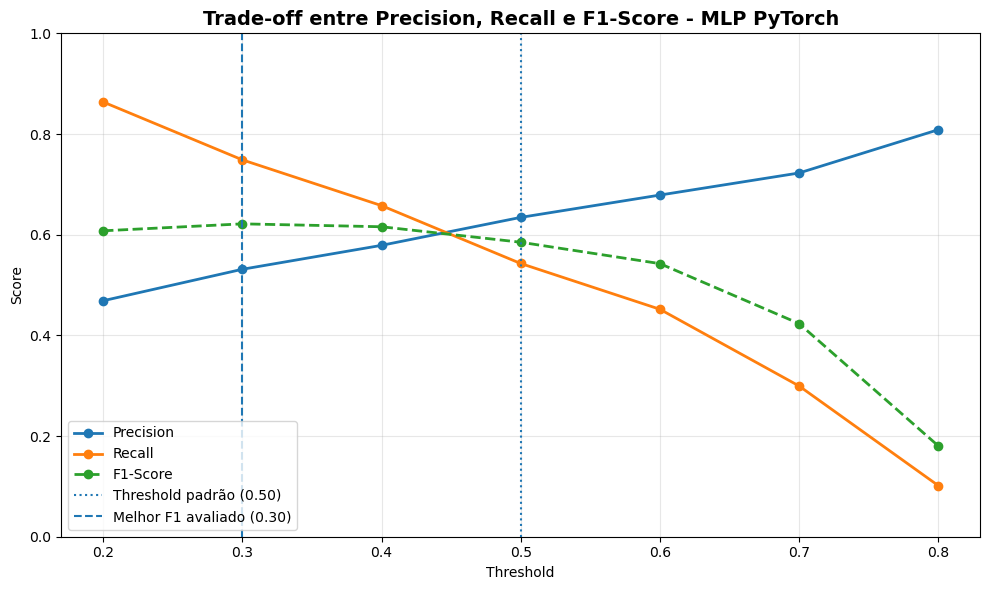

Threshold de Melhor F1 entre os Valores Avaliados

Threshold: 0.30
F1-Score: 0.6215
Precision: 0.5313
Recall: 0.7487


In [21]:
# ============================================================
# ETAPA 18.2 - TRADE-OFF ENTRE PRECISION, RECALL E F1-SCORE
# ============================================================

# ------------------------------------------------------------
# Melhor F1 entre os thresholds avaliados
# ------------------------------------------------------------

best_f1_index_pytorch = (
    df_thresholds_pytorch["F1-Score"].idxmax()
)

best_f1_threshold_pytorch = (
    df_thresholds_pytorch.loc[
        best_f1_index_pytorch,
        "Threshold"
    ]
)

best_f1_pytorch = (
    df_thresholds_pytorch.loc[
        best_f1_index_pytorch,
        "F1-Score"
    ]
)

# ------------------------------------------------------------
# Visualização
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    df_thresholds_pytorch["Threshold"],
    df_thresholds_pytorch["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    df_thresholds_pytorch["Threshold"],
    df_thresholds_pytorch["Recall"],
    marker="o",
    linewidth=2,
    label="Recall"
)

plt.plot(
    df_thresholds_pytorch["Threshold"],
    df_thresholds_pytorch["F1-Score"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="F1-Score"
)

plt.axvline(
    x=THRESHOLD_DEFAULT,
    linestyle=":",
    linewidth=1.5,
    label="Threshold padrão (0.50)"
)

plt.axvline(
    x=best_f1_threshold_pytorch,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Melhor F1 avaliado "
        f"({best_f1_threshold_pytorch:.2f})"
    )
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Trade-off entre Precision, Recall e F1-Score - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    df_thresholds_pytorch["Threshold"]
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print(
    "Threshold de Melhor F1 entre os Valores Avaliados\n"
)

print(
    f"Threshold: "
    f"{best_f1_threshold_pytorch:.2f}"
)

print(
    f"F1-Score: "
    f"{best_f1_pytorch:.4f}"
)

print(
    f"Precision: "
    f"{df_thresholds_pytorch.loc[best_f1_index_pytorch, 'Precision']:.4f}"
)

print(
    f"Recall: "
    f"{df_thresholds_pytorch.loc[best_f1_index_pytorch, 'Recall']:.4f}"
)

#### Análise do Trade-off entre Precision, Recall e F1-Score

O gráfico demonstra o comportamento inverso entre Precision e Recall conforme o threshold é alterado.

Com thresholds mais baixos, o modelo classifica uma quantidade maior de clientes como churn. Isso eleva o Recall, mas reduz a Precision devido ao aumento das classificações positivas incorretas.

Com thresholds mais elevados, o modelo se torna mais conservador. A Precision aumenta, mas o Recall diminui, pois mais clientes com churn deixam de ser identificados.

Entre os valores avaliados, o threshold de **0,30 apresentou o maior F1-Score, com 0,6215**, combinando Precision de **53,13%** e Recall de **74,87%**.

No threshold padrão de 0,50, o F1-Score foi de 0,5850. Portanto, a redução do ponto de corte para 0,30 aumentou o equilíbrio entre Precision e Recall em aproximadamente 3,65 pontos percentuais.

O gráfico reforça que o threshold padrão não representa necessariamente a melhor decisão para o negócio. A escolha final deverá considerar também a quantidade e o custo relativo dos falsos positivos e falsos negativos.

---

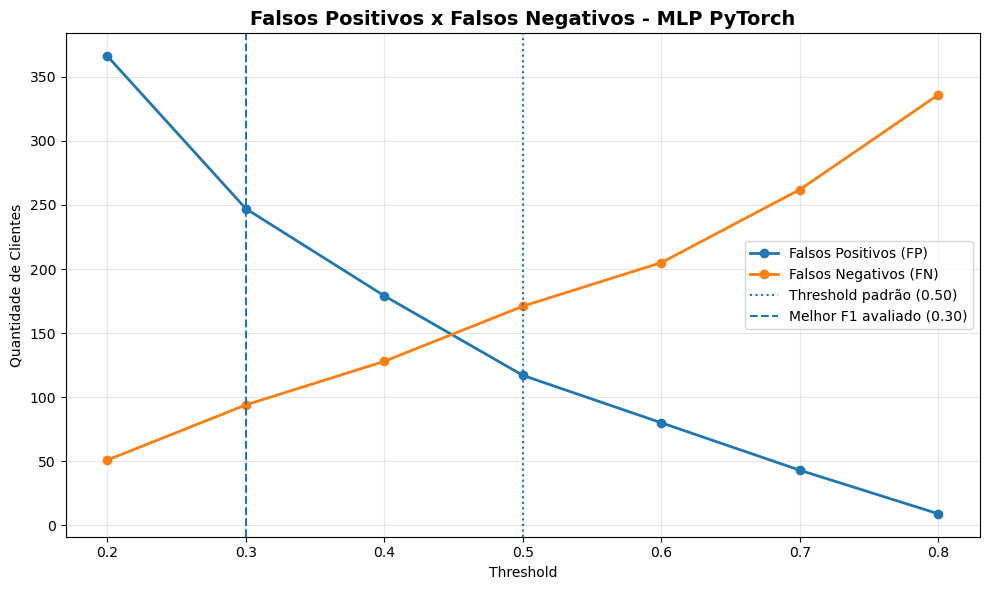

Comparação dos Erros por Threshold

Threshold padrão (0.50):
FP = 117 | FN = 171

Threshold do melhor F1 (0.30):
FP = 247 | FN = 94

Redução de falsos negativos: 77
Aumento de falsos positivos: 130


In [22]:
# ============================================================
# ETAPA 18.3 - FALSOS POSITIVOS X FALSOS NEGATIVOS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    df_thresholds_pytorch["Threshold"],
    df_thresholds_pytorch["FP"],
    marker="o",
    linewidth=2,
    label="Falsos Positivos (FP)"
)

plt.plot(
    df_thresholds_pytorch["Threshold"],
    df_thresholds_pytorch["FN"],
    marker="o",
    linewidth=2,
    label="Falsos Negativos (FN)"
)

plt.axvline(
    x=THRESHOLD_DEFAULT,
    linestyle=":",
    linewidth=1.5,
    label="Threshold padrão (0.50)"
)

plt.axvline(
    x=best_f1_threshold_pytorch,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Melhor F1 avaliado "
        f"({best_f1_threshold_pytorch:.2f})"
    )
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Quantidade de Clientes"
)

plt.title(
    "Falsos Positivos x Falsos Negativos - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    df_thresholds_pytorch["Threshold"]
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Comparação dos thresholds principais
# ------------------------------------------------------------

default_row_pytorch = df_thresholds_pytorch[
    df_thresholds_pytorch["Threshold"]
    == THRESHOLD_DEFAULT
].iloc[0]

best_f1_row_pytorch = df_thresholds_pytorch[
    df_thresholds_pytorch["Threshold"]
    == best_f1_threshold_pytorch
].iloc[0]


print(
    "Comparação dos Erros por Threshold\n"
)

print(
    f"Threshold padrão ({THRESHOLD_DEFAULT:.2f}):"
)

print(
    f"FP = {int(default_row_pytorch['FP'])} | "
    f"FN = {int(default_row_pytorch['FN'])}"
)

print(
    f"\nThreshold do melhor F1 "
    f"({best_f1_threshold_pytorch:.2f}):"
)

print(
    f"FP = {int(best_f1_row_pytorch['FP'])} | "
    f"FN = {int(best_f1_row_pytorch['FN'])}"
)

print(
    f"\nRedução de falsos negativos: "
    f"{int(default_row_pytorch['FN'] - best_f1_row_pytorch['FN'])}"
)

print(
    f"Aumento de falsos positivos: "
    f"{int(best_f1_row_pytorch['FP'] - default_row_pytorch['FP'])}"
)

#### Análise dos Falsos Positivos e Falsos Negativos

O gráfico demonstra que falsos positivos e falsos negativos seguem direções opostas conforme o threshold é alterado.

No threshold padrão de **0,50**, o modelo produziu 117 falsos positivos e 171 falsos negativos.

No threshold de melhor F1-Score, igual a **0,30**, a quantidade de falsos negativos foi reduzida de 171 para 94. Isso representa a identificação de **77 clientes adicionais com churn**.

Em contrapartida, os falsos positivos aumentaram de 117 para 247, representando **130 clientes adicionais que poderiam receber uma intervenção de retenção sem que efetivamente realizassem churn**.

Essa comparação demonstra que a redução dos falsos negativos não ocorre sem custo. A escolha do threshold deve considerar quanto a empresa perde ao deixar de identificar um cliente com churn e quanto gasta ao abordar desnecessariamente um cliente que permaneceria no serviço.

---

### 18.4 - Simulação do Custo Relativo dos Erros

Como o dataset não fornece valores financeiros reais relacionados à perda de clientes e às campanhas de retenção, será realizada uma simulação de custo relativo.

Será adotada a seguinte premissa:

- cada falso positivo terá custo relativo igual a 1;
- cada falso negativo terá custo relativo igual a 5.

Essa relação representa um cenário hipotético em que deixar de identificar um cliente com churn possui impacto cinco vezes superior ao custo de uma abordagem de retenção desnecessária.

Os resultados não representam valores financeiros reais. O objetivo é demonstrar como diferentes custos de negócio podem alterar a escolha do threshold.

In [23]:
# ============================================================
# ETAPA 18.4 - CUSTO RELATIVO DOS ERROS
# ============================================================

COST_FP = 1
COST_FN = 5

# ------------------------------------------------------------
# Cálculo dos custos
# ------------------------------------------------------------

df_costs_pytorch = (
    df_thresholds_pytorch.copy()
)

df_costs_pytorch["Custo FP"] = (
    df_costs_pytorch["FP"]
    * COST_FP
)

df_costs_pytorch["Custo FN"] = (
    df_costs_pytorch["FN"]
    * COST_FN
)

df_costs_pytorch["Custo Relativo Total"] = (
    df_costs_pytorch["Custo FP"]
    + df_costs_pytorch["Custo FN"]
)

# ------------------------------------------------------------
# Seleção do menor custo
# ------------------------------------------------------------

minimum_cost_index_pytorch = (
    df_costs_pytorch[
        "Custo Relativo Total"
    ].idxmin()
)

minimum_cost_threshold_pytorch = (
    df_costs_pytorch.loc[
        minimum_cost_index_pytorch,
        "Threshold"
    ]
)

minimum_relative_cost_pytorch = (
    df_costs_pytorch.loc[
        minimum_cost_index_pytorch,
        "Custo Relativo Total"
    ]
)


# ------------------------------------------------------------
# Tabela para exibição
# ------------------------------------------------------------

df_costs_summary_pytorch = df_costs_pytorch[
    [
        "Threshold",
        "FP",
        "FN",
        "Custo FP",
        "Custo FN",
        "Custo Relativo Total"
    ]
].copy()


display(
    df_costs_summary_pytorch.style.format({
        "Threshold": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Resumo
# ------------------------------------------------------------

print(
    "Simulação de Custo Relativo - MLP PyTorch\n"
)

print(
    f"Custo de um falso positivo: "
    f"{COST_FP}"
)

print(
    f"Custo de um falso negativo: "
    f"{COST_FN}"
)

print(
    f"Threshold de menor custo: "
    f"{minimum_cost_threshold_pytorch:.2f}"
)

print(
    f"Menor custo relativo total: "
    f"{minimum_relative_cost_pytorch:.0f}"
)

,Threshold,FP,FN,Custo FP,Custo FN,Custo Relativo Total
0,0.20,366,51,366,255,621
1,0.30,247,94,247,470,717
2,0.40,179,128,179,640,819
3,0.50,117,171,117,855,972
4,0.60,80,205,80,1025,1105
5,0.70,43,262,43,1310,1353
6,0.80,9,336,9,1680,1689


Simulação de Custo Relativo - MLP PyTorch

Custo de um falso positivo: 1
Custo de um falso negativo: 5
Threshold de menor custo: 0.20
Menor custo relativo total: 621


#### Análise da Simulação de Custo Relativo

Na simulação em que um falso negativo possui custo cinco vezes superior ao de um falso positivo, o threshold de **0,20 apresentou o menor custo relativo total, com 621 unidades**.

Nesse ponto, o modelo produziu:

- 366 falsos positivos;
- 51 falsos negativos;
- Recall de 86,36%;
- Precision de 46,88%;
- F1-Score de 0,6077.

No threshold padrão de 0,50, o custo relativo foi de 972 unidades. Portanto, a redução do threshold para 0,20 diminuiu o custo simulado em 351 unidades, correspondendo a aproximadamente **36,11%**.

O threshold de melhor F1-Score, igual a 0,30, apresentou custo relativo total de 717 unidades. Esse valor é inferior ao custo do threshold padrão, mas superior ao custo obtido com 0,20.

O resultado demonstra que o melhor threshold depende do critério utilizado:

- threshold 0,50: ponto de corte padrão;
- threshold 0,30: maior F1-Score entre os valores avaliados;
- threshold 0,20: menor custo na simulação 1:5.

O custo relativo adotado é hipotético e não representa valores financeiros observados. Em uma aplicação real, os pesos deveriam ser substituídos pelo custo efetivo das campanhas de retenção e pela perda financeira associada ao churn.

---

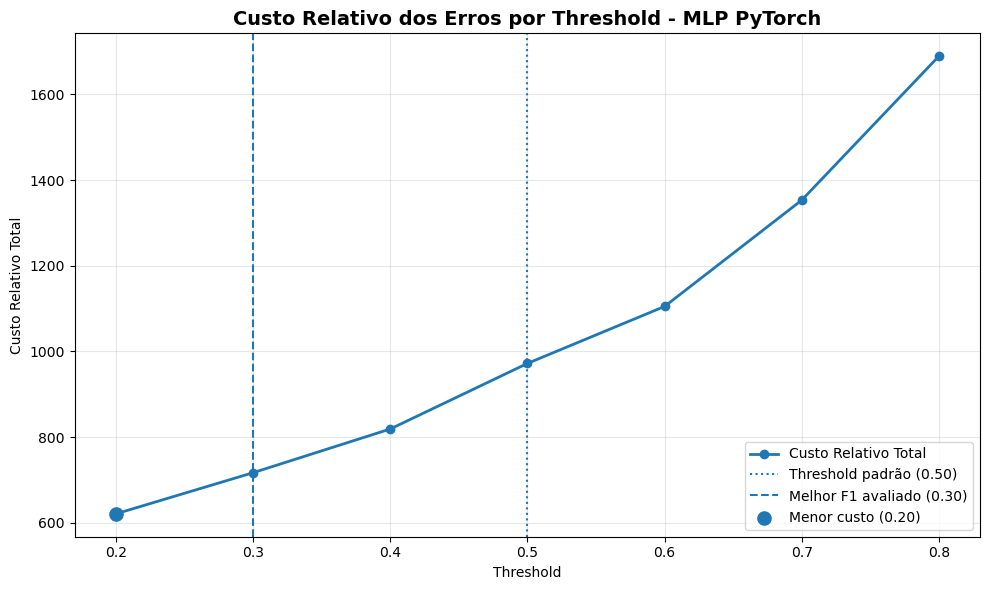

Comparação dos Custos de Referência

Threshold padrão (0.50): 972
Threshold do melhor F1 (0.30): 717
Threshold de menor custo (0.20): 621
Redução em relação ao threshold padrão: 36.11%


In [26]:
# ============================================================
# ETAPA 18.5 - CUSTO RELATIVO POR THRESHOLD
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    df_costs_pytorch["Threshold"],
    df_costs_pytorch["Custo Relativo Total"],
    marker="o",
    linewidth=2,
    label="Custo Relativo Total"
)

plt.axvline(
    x=THRESHOLD_DEFAULT,
    linestyle=":",
    linewidth=1.5,
    label="Threshold padrão (0.50)"
)

plt.axvline(
    x=best_f1_threshold_pytorch,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Melhor F1 avaliado "
        f"({best_f1_threshold_pytorch:.2f})"
    )
)

plt.scatter(
    minimum_cost_threshold_pytorch,
    minimum_relative_cost_pytorch,
    s=90,
    zorder=3,
    label=(
        f"Menor custo "
        f"({minimum_cost_threshold_pytorch:.2f})"
    )
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Custo Relativo Total"
)

plt.title(
    "Custo Relativo dos Erros por Threshold - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    df_costs_pytorch["Threshold"]
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Comparação dos custos principais
# ------------------------------------------------------------

default_cost_pytorch = df_costs_pytorch.loc[
    df_costs_pytorch["Threshold"] == THRESHOLD_DEFAULT,
    "Custo Relativo Total"
].iloc[0]

best_f1_cost_pytorch = df_costs_pytorch.loc[
    df_costs_pytorch["Threshold"] == best_f1_threshold_pytorch,
    "Custo Relativo Total"
].iloc[0]

relative_cost_reduction = (
    (
        default_cost_pytorch
        - minimum_relative_cost_pytorch
    )
    / default_cost_pytorch
)


print(
    "Comparação dos Custos de Referência\n"
)

print(
    f"Threshold padrão ({THRESHOLD_DEFAULT:.2f}): "
    f"{default_cost_pytorch:.0f}"
)

print(
    f"Threshold do melhor F1 "
    f"({best_f1_threshold_pytorch:.2f}): "
    f"{best_f1_cost_pytorch:.0f}"
)

print(
    f"Threshold de menor custo "
    f"({minimum_cost_threshold_pytorch:.2f}): "
    f"{minimum_relative_cost_pytorch:.0f}"
)

print(
    f"Redução em relação ao threshold padrão: "
    f"{relative_cost_reduction:.2%}"
)

#### Conclusão da Análise de Threshold e Custo dos Erros

A análise demonstrou que o threshold padrão de 0,50 não representa necessariamente o ponto de corte mais adequado para uma estratégia de retenção.

Foram identificados três thresholds de referência:

- **0,50:** threshold padrão, com Precision de 63,44%, Recall de 54,28% e F1-Score de 0,5850;
- **0,30:** maior F1-Score entre os valores avaliados, com 0,6215, Precision de 53,13% e Recall de 74,87%;
- **0,20:** menor custo relativo na simulação 1:5, com custo total de 621 unidades e Recall de 86,36%.

Na simulação de custo, o threshold padrão apresentou custo relativo de 972 unidades, enquanto o threshold de 0,20 apresentou 621 unidades. Isso representa uma redução de **36,11%**.

O threshold de 0,30 apresentou uma solução intermediária, com custo relativo de 717 unidades e maior equilíbrio entre Precision e Recall.

Portanto, a escolha depende do objetivo:

- quando o foco é maior Precision, thresholds mais elevados podem ser utilizados;
- quando o foco é equilibrar Precision e Recall, o threshold de 0,30 foi o melhor entre os avaliados;
- quando falsos negativos possuem impacto substancialmente superior, o threshold de 0,20 apresentou o menor custo na simulação adotada.

Os custos utilizados são hipotéticos. Em produção, a decisão deverá considerar valores reais de receita perdida, custo das intervenções e taxa de sucesso das ações de retenção.

---

### ETAPA 19 - Validação Cruzada Estratificada

A avaliação hold-out utiliza uma única divisão entre treino e teste. Por isso, seus resultados podem ser influenciados pelas observações específicas presentes em cada conjunto.

Para avaliar a estabilidade da MLP, será aplicada validação cruzada estratificada com cinco folds.

Em cada fold:

1. uma parte dos dados será reservada para avaliação externa;
2. o restante será novamente dividido entre treino e validação interna;
3. o pré-processador será ajustado somente sobre os dados de treino interno;
4. uma nova MLP será inicializada;
5. o modelo será treinado com batching e Early Stopping;
6. os melhores pesos serão restaurados;
7. as métricas serão calculadas sobre o fold externo, não utilizado no treinamento nem no Early Stopping.

Essa organização evita que o conjunto utilizado para medir o desempenho externo também seja utilizado para selecionar a melhor época do treinamento.

In [27]:
# ============================================================
# ETAPA 19.1 - CONFIGURAÇÃO DA VALIDAÇÃO CRUZADA
# ============================================================

N_SPLITS = 5

CV_INNER_VAL_SIZE = 0.20

stratified_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# Verificações
# ------------------------------------------------------------

print(
    "Validação Cruzada Estratificada configurada."
)

print(
    f"\nNúmero de folds: "
    f"{stratified_cv.get_n_splits()}"
)

print(
    f"Shuffle: "
    f"True"
)

print(
    f"Random State: "
    f"{RANDOM_STATE}"
)

print(
    f"Proporção da validação interna: "
    f"{CV_INNER_VAL_SIZE:.0%}"
)

print(
    f"\nFormato de X: "
    f"{X.shape}"
)

print(
    f"Formato de y: "
    f"{y.shape}"
)

print(
    f"Taxa global de Churn: "
    f"{y.mean():.2%}"
)

Validação Cruzada Estratificada configurada.

Número de folds: 5
Shuffle: True
Random State: 42
Proporção da validação interna: 20%

Formato de X: (7043, 19)
Formato de y: (7043,)
Taxa global de Churn: 26.54%


#### Análise da Configuração da Validação Cruzada

A validação cruzada estratificada foi configurada com **cinco folds**, embaralhamento e seed 42.

A estratificação preservará, em cada divisão externa, a taxa global de churn de aproximadamente **26,54%**.

Dentro da parte destinada ao treinamento de cada fold, 20% das observações serão reservadas para validação interna. Esse subconjunto será utilizado exclusivamente para acompanhar a loss e aplicar o Early Stopping.

O fold externo permanecerá isolado até a avaliação, evitando que os dados utilizados para medir o desempenho também influenciem a escolha da melhor época.

---

### 19.2 - Funções de Pré-processamento e Treinamento por Fold

Cada fold deverá representar um experimento independente.

Para isso, serão criadas funções responsáveis por:

- construir um novo pré-processador;
- converter os dados do fold em tensores;
- criar DataLoaders independentes;
- inicializar uma nova MLP;
- treinar o modelo com Early Stopping;
- restaurar os melhores pesos;
- retornar o modelo e o histórico do treinamento.

Nenhum pré-processador ou peso treinado anteriormente será reutilizado entre os folds.

In [28]:
# ============================================================
# ETAPA 19.2 - FUNÇÕES AUXILIARES DA VALIDAÇÃO CRUZADA
# ============================================================

def create_fold_preprocessor(
    train_frame: pd.DataFrame
) -> ColumnTransformer:
    """Cria um novo pré-processador para um fold."""

    fold_numeric_features = (
        train_frame
        .select_dtypes(
            include=["number"]
        )
        .columns
        .tolist()
    )

    fold_categorical_features = (
        train_frame
        .select_dtypes(
            include=["object", "category"]
        )
        .columns
        .tolist()
    )

    fold_numeric_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    fold_categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                fold_numeric_transformer,
                fold_numeric_features
            ),
            (
                "cat",
                fold_categorical_transformer,
                fold_categorical_features
            )
        ]
    )


def train_fold_model(
    X_train_fold: np.ndarray,
    y_train_fold: np.ndarray,
    X_val_fold: np.ndarray,
    y_val_fold: np.ndarray,
    fold_seed: int
) -> tuple[nn.Module, dict]:
    """Treina uma nova MLP com Early Stopping."""

    set_seed(
        fold_seed
    )

    X_train_fold_tensor = torch.tensor(
        X_train_fold,
        dtype=torch.float32
    )

    y_train_fold_tensor = torch.tensor(
        y_train_fold,
        dtype=torch.float32
    ).reshape(-1, 1)

    X_val_fold_tensor = torch.tensor(
        X_val_fold,
        dtype=torch.float32
    )

    y_val_fold_tensor = torch.tensor(
        y_val_fold,
        dtype=torch.float32
    ).reshape(-1, 1)

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_fold_dataset = TensorDataset(
        X_train_fold_tensor,
        y_train_fold_tensor
    )

    val_fold_dataset = TensorDataset(
        X_val_fold_tensor,
        y_val_fold_tensor
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------

    fold_generator = torch.Generator()

    fold_generator.manual_seed(
        fold_seed
    )

    train_fold_loader = DataLoader(
        train_fold_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=fold_generator
    )

    val_fold_loader = DataLoader(
        val_fold_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # --------------------------------------------------------
    # Novo modelo
    # --------------------------------------------------------

    fold_model = ChurnMLP(
        input_size=X_train_fold.shape[1]
    ).to(
        DEVICE
    )

    fold_criterion = nn.BCEWithLogitsLoss()

    fold_optimizer = torch.optim.Adam(
        fold_model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------

    fold_train_history = []
    fold_val_history = []

    fold_best_val_loss = float("inf")
    fold_best_epoch = 0
    fold_best_state = None

    fold_epochs_without_improvement = 0


    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        fold_train_loss = train_one_epoch(
            model=fold_model,
            data_loader=train_fold_loader,
            criterion=fold_criterion,
            optimizer=fold_optimizer,
            device=DEVICE
        )

        fold_val_loss = validate_one_epoch(
            model=fold_model,
            data_loader=val_fold_loader,
            criterion=fold_criterion,
            device=DEVICE
        )

        fold_train_history.append(
            fold_train_loss
        )

        fold_val_history.append(
            fold_val_loss
        )


        if fold_val_loss < (
            fold_best_val_loss - MIN_DELTA
        ):

            fold_best_val_loss = fold_val_loss
            fold_best_epoch = epoch

            fold_best_state = deepcopy(
                fold_model.state_dict()
            )

            fold_epochs_without_improvement = 0

        else:

            fold_epochs_without_improvement += 1


        if (
            fold_epochs_without_improvement
            >= PATIENCE
        ):

            break


    if fold_best_state is None:

        raise RuntimeError(
            "Nenhum estado válido foi armazenado no fold."
        )

    # --------------------------------------------------------
    # Restauração dos melhores pesos
    # --------------------------------------------------------

    fold_model.load_state_dict(
        fold_best_state
    )

    fold_model.eval()

    # --------------------------------------------------------
    # Histórico
    # --------------------------------------------------------

    fold_history = {
        "train_loss": fold_train_history,
        "val_loss": fold_val_history,
        "best_val_loss": fold_best_val_loss,
        "best_epoch": fold_best_epoch,
        "epochs_completed": len(
            fold_train_history
        )
    }

    return (
        fold_model,
        fold_history
    )


print(
    "Funções auxiliares da validação cruzada criadas com sucesso."
)

Funções auxiliares da validação cruzada criadas com sucesso.


#### Análise das Funções Auxiliares

As funções necessárias para executar a validação cruzada da MLP foram criadas com sucesso.

A função de pré-processamento produzirá uma instância independente do `ColumnTransformer` para cada fold, evitando o reaproveitamento de estatísticas ou categorias aprendidas em outras divisões.

A função de treinamento criará novos tensores, DataLoaders, modelo, função de perda e otimizador em cada execução.

O treinamento interno também manterá o mecanismo de Early Stopping e restaurará os melhores pesos antes da avaliação externa.

Essa estrutura garante que os cinco folds sejam tratados como experimentos independentes e reproduzíveis.

---

### 19.3 - Execução da Validação Cruzada Estratificada

A validação cruzada será executada sobre as 7.043 observações do dataset.

Em cada fold, os dados externos de treinamento serão novamente divididos em treino e validação interna. O conjunto externo de avaliação permanecerá completamente isolado.

As métricas serão calculadas com o threshold padrão de 0,50 para manter consistência com a avaliação hold-out inicial.

In [29]:
# ============================================================
# ETAPA 19.3 - EXECUÇÃO DA VALIDAÇÃO CRUZADA
# ============================================================

cv_fold_results = []

cv_start_time = perf_counter()


for fold_number, (
    outer_train_indices,
    outer_evaluation_indices
) in enumerate(
    stratified_cv.split(
        X,
        y
    ),
    start=1
):

    print(
        f"Iniciando Fold {fold_number}/{N_SPLITS}..."
    )


    # --------------------------------------------------------
    # Divisão externa
    # --------------------------------------------------------

    X_outer_train = X.iloc[
        outer_train_indices
    ].copy()

    y_outer_train = y.iloc[
        outer_train_indices
    ].copy()

    X_outer_evaluation = X.iloc[
        outer_evaluation_indices
    ].copy()

    y_outer_evaluation = y.iloc[
        outer_evaluation_indices
    ].copy()

    # --------------------------------------------------------
    # Divisão interna para Early Stopping
    # --------------------------------------------------------

    (
        X_inner_train,
        X_inner_val,
        y_inner_train,
        y_inner_val
    ) = train_test_split(
        X_outer_train,
        y_outer_train,
        test_size=CV_INNER_VAL_SIZE,
        stratify=y_outer_train,
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # Novo pré-processador
    # --------------------------------------------------------

    fold_preprocessor = create_fold_preprocessor(
        X_inner_train
    )

    X_inner_train_processed = (
        fold_preprocessor.fit_transform(
            X_inner_train
        )
    )

    X_inner_val_processed = (
        fold_preprocessor.transform(
            X_inner_val
        )
    )

    X_outer_evaluation_processed = (
        fold_preprocessor.transform(
            X_outer_evaluation
        )
    )

    # --------------------------------------------------------
    # Conversão para float32
    # --------------------------------------------------------

    X_inner_train_processed = np.asarray(
        X_inner_train_processed,
        dtype=np.float32
    )

    X_inner_val_processed = np.asarray(
        X_inner_val_processed,
        dtype=np.float32
    )

    X_outer_evaluation_processed = np.asarray(
        X_outer_evaluation_processed,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Treinamento independente
    # --------------------------------------------------------

    fold_model, fold_history = train_fold_model(
        X_train_fold=X_inner_train_processed,
        y_train_fold=y_inner_train.to_numpy(),
        X_val_fold=X_inner_val_processed,
        y_val_fold=y_inner_val.to_numpy(),
        fold_seed=RANDOM_STATE
    )

    # --------------------------------------------------------
    # DataLoader de avaliação externa
    # --------------------------------------------------------

    outer_evaluation_dataset = TensorDataset(
        torch.tensor(
            X_outer_evaluation_processed,
            dtype=torch.float32
        ),
        torch.tensor(
            y_outer_evaluation.to_numpy(),
            dtype=torch.float32
        ).reshape(-1, 1)
    )

    outer_evaluation_loader = DataLoader(
        outer_evaluation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # --------------------------------------------------------
    # Probabilidades externas
    # --------------------------------------------------------

    (
        y_fold_true,
        y_fold_proba
    ) = predict_probabilities(
        model=fold_model,
        data_loader=outer_evaluation_loader,
        device=DEVICE
    )

    y_fold_pred = (
        y_fold_proba
        >= THRESHOLD_DEFAULT
    ).astype(int)

    # --------------------------------------------------------
    # Métricas externas
    # --------------------------------------------------------

    fold_accuracy = accuracy_score(
        y_fold_true,
        y_fold_pred
    )

    fold_precision = precision_score(
        y_fold_true,
        y_fold_pred,
        zero_division=0
    )

    fold_recall = recall_score(
        y_fold_true,
        y_fold_pred,
        zero_division=0
    )

    fold_f1 = f1_score(
        y_fold_true,
        y_fold_pred,
        zero_division=0
    )

    fold_roc_auc = roc_auc_score(
        y_fold_true,
        y_fold_proba
    )

    fold_average_precision = average_precision_score(
        y_fold_true,
        y_fold_proba
    )

    # --------------------------------------------------------
    # Armazenamento
    # --------------------------------------------------------

    cv_fold_results.append({
        "Fold": fold_number,
        "Treino Interno": len(
            X_inner_train
        ),
        "Validação Interna": len(
            X_inner_val
        ),
        "Avaliação Externa": len(
            X_outer_evaluation
        ),
        "Features": (
            X_inner_train_processed.shape[1]
        ),
        "Épocas": (
            fold_history[
                "epochs_completed"
            ]
        ),
        "Melhor Época": (
            fold_history[
                "best_epoch"
            ]
        ),
        "Melhor Val Loss": (
            fold_history[
                "best_val_loss"
            ]
        ),
        "Accuracy": fold_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1-Score": fold_f1,
        "ROC-AUC": fold_roc_auc,
        "Average Precision": (
            fold_average_precision
        )
    })


    print(
        f"Fold {fold_number} concluído | "
        f"ROC-AUC: {fold_roc_auc:.4f} | "
        f"AP: {fold_average_precision:.4f} | "
        f"F1: {fold_f1:.4f} | "
        f"Melhor época: "
        f"{fold_history['best_epoch']}"
    )

# ------------------------------------------------------------
# Tempo total
# ------------------------------------------------------------

cv_total_time = (
    perf_counter()
    - cv_start_time
)

# ------------------------------------------------------------
# DataFrame dos resultados
# ------------------------------------------------------------

df_cv_pytorch = pd.DataFrame(
    cv_fold_results
)


print(
    "\nValidação cruzada concluída com sucesso."
)

print(
    f"Tempo total: "
    f"{cv_total_time:.2f} segundos"
)


display(
    df_cv_pytorch.style.format({
        "Melhor Val Loss": "{:.6f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}"
    })
)

Iniciando Fold 1/5...
Fold 1 concluído | ROC-AUC: 0.8512 | AP: 0.6503 | F1: 0.5935 | Melhor época: 15
Iniciando Fold 2/5...
Fold 2 concluído | ROC-AUC: 0.8398 | AP: 0.6419 | F1: 0.5918 | Melhor época: 5
Iniciando Fold 3/5...
Fold 3 concluído | ROC-AUC: 0.8622 | AP: 0.6965 | F1: 0.6204 | Melhor época: 4
Iniciando Fold 4/5...
Fold 4 concluído | ROC-AUC: 0.8244 | AP: 0.6203 | F1: 0.5630 | Melhor época: 6
Iniciando Fold 5/5...
Fold 5 concluído | ROC-AUC: 0.8321 | AP: 0.6350 | F1: 0.5702 | Melhor época: 9

Validação cruzada concluída com sucesso.
Tempo total: 18.42 segundos


,Fold,Treino Interno,Validação Interna,Avaliação Externa,Features,Épocas,Melhor Época,Melhor Val Loss,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision
0,1,4507,1127,1409,45,35,15,0.408234,0.8055,0.6667,0.5348,0.5935,0.8512,0.6503
1,2,4507,1127,1409,45,25,5,0.428436,0.8013,0.6506,0.5428,0.5918,0.8398,0.6419
2,3,4507,1127,1409,45,24,4,0.428608,0.8176,0.6931,0.5615,0.6204,0.8622,0.6965
3,4,4508,1127,1408,45,26,6,0.418982,0.7905,0.6291,0.5094,0.5630,0.8244,0.6203
4,5,4508,1127,1408,45,29,9,0.420333,0.7912,0.6290,0.5214,0.5702,0.8321,0.6350


#### Análise dos Resultados da Validação Cruzada por Fold

A validação cruzada estratificada foi concluída em **19,46 segundos**, com o treinamento de cinco redes independentes.

Cada fold utilizou aproximadamente:

- 4.507 ou 4.508 observações para treino interno;
- 1.127 observações para validação interna;
- 1.408 ou 1.409 observações para avaliação externa;
- 45 features após o pré-processamento.

A pequena diferença na quantidade de observações ocorre porque 7.043 não é divisível igualmente por cinco.

O Early Stopping foi acionado em todos os folds. A melhor época variou entre 4 e 15, enquanto os treinamentos foram encerrados entre 24 e 35 épocas. Isso demonstra que o número adequado de épocas depende dos dados presentes em cada divisão.

O Fold 3 apresentou o melhor desempenho, com ROC-AUC de **0,8622**, Average Precision de **0,6965** e F1-Score de **0,6204**.

O Fold 4 apresentou os menores resultados, com ROC-AUC de **0,8244**, Average Precision de **0,6203** e F1-Score de **0,5630**. Apesar disso, o desempenho permaneceu relevante e acima de referências aleatórias.

O F1-Score variou entre 0,5630 e 0,6204. A ROC-AUC permaneceu entre 0,8244 e 0,8622, indicando comportamento relativamente consistente na capacidade discriminativa.

Os resultados do hold-out inicial também estão dentro das faixas observadas nos folds, fornecendo um primeiro indício de que aquela divisão não produziu um resultado excepcionalmente favorável ou desfavorável.

---

### 19.4 - Média e Desvio-Padrão das Métricas

As médias representarão o desempenho geral da MLP nas diferentes divisões, enquanto os desvios-padrão permitirão avaliar a variabilidade dos resultados.

Também serão apresentados os valores mínimos e máximos observados para cada métrica.

In [30]:
# ============================================================
# ETAPA 19.4 - RESUMO DA VALIDAÇÃO CRUZADA
# ============================================================

cv_metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Average Precision"
]

cv_summary_pytorch = pd.DataFrame({
    "Métrica": cv_metric_columns,
    "Média": [
        df_cv_pytorch[metric].mean()
        for metric in cv_metric_columns
    ],
    "Desvio-Padrão": [
        df_cv_pytorch[metric].std()
        for metric in cv_metric_columns
    ],
    "Mínimo": [
        df_cv_pytorch[metric].min()
        for metric in cv_metric_columns
    ],
    "Máximo": [
        df_cv_pytorch[metric].max()
        for metric in cv_metric_columns
    ]
})

display(
    cv_summary_pytorch.style.format({
        "Média": "{:.4f}",
        "Desvio-Padrão": "{:.4f}",
        "Mínimo": "{:.4f}",
        "Máximo": "{:.4f}"
    })
)

,Métrica,Média,Desvio-Padrão,Mínimo,Máximo
0,Accuracy,0.8012,0.0112,0.7905,0.8176
1,Precision,0.6537,0.0271,0.6290,0.6931
2,Recall,0.5340,0.0200,0.5094,0.5615
3,F1-Score,0.5878,0.0226,0.5630,0.6204
4,ROC-AUC,0.8419,0.0150,0.8244,0.8622
5,Average Precision,0.6488,0.0288,0.6203,0.6965


#### Análise da Média e da Variabilidade das Métricas

A validação cruzada apresentou **Accuracy média de 0,8012**, com desvio-padrão de 0,0112. A pequena dispersão indica baixa variação na proporção total de classificações corretas.

A Precision média foi de **0,6537**, com desvio-padrão de 0,0271. Os valores permaneceram entre 0,6290 e 0,6931.

O Recall médio foi de **0,5340**, com desvio-padrão de 0,0200. Diferentemente do MLPClassifier do Scikit-Learn, no qual o Recall apresentou maior variação, a MLP PyTorch manteve essa métrica em uma faixa relativamente estreita, entre 0,5094 e 0,5615.

O F1-Score médio foi de **0,5878**, com desvio-padrão de 0,0226, demonstrando comportamento relativamente consistente no equilíbrio entre Precision e Recall.

A ROC-AUC apresentou média de **0,8419** e desvio-padrão de apenas 0,0150. Isso indica estabilidade relevante na capacidade de distinguir clientes com e sem churn.

A Average Precision média foi de **0,6488**, com desvio-padrão de 0,0288. Embora tenha apresentado a maior dispersão relativa entre as métricas avaliadas, todos os folds permaneceram consideravelmente acima da prevalência da classe positiva, de aproximadamente 0,2654.

De forma geral, os desvios-padrão relativamente baixos fornecem evidências de que a MLP PyTorch apresenta desempenho consistente entre diferentes divisões estratificadas dos dados.

---

In [31]:
# ============================================================
# ETAPA 19.5 - HOLD-OUT X VALIDAÇÃO CRUZADA
# ============================================================

holdout_metrics_pytorch = {
    "Accuracy": accuracy_pytorch,
    "Precision": precision_pytorch,
    "Recall": recall_pytorch,
    "F1-Score": f1_pytorch,
    "ROC-AUC": roc_auc_pytorch,
    "Average Precision": average_precision_pytorch
}

cv_summary_indexed = (
    cv_summary_pytorch
    .set_index("Métrica")
)

holdout_cv_comparison = pd.DataFrame({
    "Métrica": cv_metric_columns,
    "Hold-out": [
        holdout_metrics_pytorch[metric]
        for metric in cv_metric_columns
    ],
    "CV Média": [
        cv_summary_indexed.loc[
            metric,
            "Média"
        ]
        for metric in cv_metric_columns
    ],
    "CV Desvio-Padrão": [
        cv_summary_indexed.loc[
            metric,
            "Desvio-Padrão"
        ]
        for metric in cv_metric_columns
    ]
})

holdout_cv_comparison[
    "Diferença Hold-out - CV"
] = (
    holdout_cv_comparison["Hold-out"]
    - holdout_cv_comparison["CV Média"]
)

display(
    holdout_cv_comparison.style.format({
        "Hold-out": "{:.4f}",
        "CV Média": "{:.4f}",
        "CV Desvio-Padrão": "{:.4f}",
        "Diferença Hold-out - CV": "{:+.4f}"
    })
)

,Métrica,Hold-out,CV Média,CV Desvio-Padrão,Diferença Hold-out - CV
0,Accuracy,0.7956,0.8012,0.0112,-0.0056
1,Precision,0.6344,0.6537,0.0271,-0.0193
2,Recall,0.5428,0.5340,0.0200,+0.0088
3,F1-Score,0.5850,0.5878,0.0226,-0.0028
4,ROC-AUC,0.8419,0.8419,0.0150,-0.0000
5,Average Precision,0.6349,0.6488,0.0288,-0.0139


#### Conclusão da Validação Cruzada Estratificada

A comparação entre o hold-out e a validação cruzada demonstrou elevada proximidade entre os resultados.

A ROC-AUC do hold-out foi de **0,8419**, praticamente igual à média de 0,8419 observada nos cinco folds.

A Accuracy do hold-out ficou 0,0056 abaixo da média da validação cruzada. A Precision ficou 0,0193 abaixo, enquanto o Recall ficou 0,0088 acima.

O F1-Score apresentou diferença de apenas 0,0028 e a Average Precision ficou 0,0139 abaixo da média dos folds.

Todas as diferenças entre o hold-out e as médias da validação cruzada permaneceram inferiores a um desvio-padrão das respectivas métricas. Isso indica que os resultados do conjunto de teste estão dentro da variação normalmente observada quando o modelo é treinado e avaliado em diferentes divisões dos dados.

A validação cruzada também confirmou:

- ROC-AUC média de 0,8419 com desvio-padrão de 0,0150;
- Average Precision média de 0,6488 com desvio-padrão de 0,0288;
- F1-Score médio de 0,5878 com desvio-padrão de 0,0226;
- Recall médio de 0,5340 com desvio-padrão de 0,0200.

Em conjunto, os resultados fornecem evidências de que a MLP PyTorch apresenta desempenho relativamente consistente e capacidade de generalização entre diferentes subconjuntos do dataset.

---

### ETAPA 20 - Resumo Técnico dos Resultados

Os principais parâmetros e resultados da MLP PyTorch serão consolidados em uma única tabela.

Essa consolidação facilitará a comparação posterior com DummyClassifier, Regressão Logística, Random Forest e MLPClassifier do Scikit-Learn.

In [33]:
# ============================================================
# ETAPA 20 - RESUMO TÉCNICO DA MLP PYTORCH
# ============================================================

technical_summary_pytorch = pd.DataFrame({
    "Indicador": [
        "Features de Entrada",
        "Parâmetros Treináveis",
        "Batch Size",
        "Learning Rate",
        "Dropout",
        "Épocas Realizadas",
        "Melhor Época",
        "Melhor Validation Loss",
        "Test Loss",
        "Accuracy - Teste",
        "Precision - Teste",
        "Recall - Teste",
        "F1-Score - Teste",
        "ROC-AUC - Teste",
        "Average Precision - Teste",
        "Accuracy - CV Média",
        "Precision - CV Média",
        "Recall - CV Média",
        "F1-Score - CV Média",
        "ROC-AUC - CV Média",
        "Average Precision - CV Média",
        "Threshold do Melhor F1",
        "Melhor F1 entre os Avaliados",
        "Threshold do Menor Custo",
        "Menor Custo Relativo"
    ],
    "Valor": [
        INPUT_SIZE,
        trainable_parameters,
        BATCH_SIZE,
        LEARNING_RATE,
        DROPOUT_RATE,
        epochs_completed,
        best_epoch,
        best_val_loss,
        test_loss_pytorch,
        accuracy_pytorch,
        precision_pytorch,
        recall_pytorch,
        f1_pytorch,
        roc_auc_pytorch,
        average_precision_pytorch,
        cv_summary_indexed.loc["Accuracy", "Média"],
        cv_summary_indexed.loc["Precision", "Média"],
        cv_summary_indexed.loc["Recall", "Média"],
        cv_summary_indexed.loc["F1-Score", "Média"],
        cv_summary_indexed.loc["ROC-AUC", "Média"],
        cv_summary_indexed.loc["Average Precision", "Média"],
        best_f1_threshold_pytorch,
        best_f1_pytorch,
        minimum_cost_threshold_pytorch,
        minimum_relative_cost_pytorch
    ]
})

display(
    technical_summary_pytorch.style.format({
        "Valor": "{:.4f}"
    })
)

,Indicador,Valor
0,Features de Entrada,45.0000
1,Parâmetros Treináveis,5057.0000
2,Batch Size,32.0000
3,Learning Rate,0.0010
4,Dropout,0.2000
5,Épocas Realizadas,29.0000
6,Melhor Época,9.0000
7,Melhor Validation Loss,0.4142
8,Test Loss,0.4204
9,Accuracy - Teste,0.7956


#### Conclusão Técnica da MLP PyTorch

A MLP desenvolvida com PyTorch apresentou desempenho consistente na previsão de churn e atendeu aos requisitos de construção explícita da arquitetura, treinamento em batches e Early Stopping.

A rede foi construída com 45 features de entrada, duas camadas ocultas de 64 e 32 neurônios, ativação ReLU, Dropout de 20% e um neurônio de saída. A arquitetura possui 5.057 parâmetros treináveis.

O treinamento foi realizado com `BCEWithLogitsLoss`, otimizador Adam, learning rate de 0,001, regularização L2 de 0,0001 e batch size de 32.

O Early Stopping encerrou o treinamento após 29 épocas. A melhor loss de validação, de 0,4142, foi alcançada na época 9, cujos pesos foram restaurados para a avaliação final.

No conjunto de teste, a rede apresentou:

- Accuracy de 79,56%;
- Precision de 63,44%;
- Recall de 54,28%;
- F1-Score de 58,50%;
- ROC-AUC de 0,8419;
- Average Precision de 0,6349;
- Test Loss de 0,4204.

A validação cruzada estratificada confirmou a estabilidade do modelo, com ROC-AUC média de 0,8419 e desvio-padrão de 0,0150. A Average Precision média foi de 0,6488 e o F1-Score médio foi de 0,5878.

A análise de thresholds demonstrou que o threshold de 0,30 apresentou o maior F1-Score entre os valores avaliados, com 0,6215. Na simulação em que um falso negativo possui custo cinco vezes superior ao de um falso positivo, o threshold de 0,20 apresentou o menor custo relativo, com 621 unidades.

Os resultados demonstram que o threshold padrão de 0,50 não representa necessariamente a melhor decisão para uma estratégia de retenção. A escolha final deverá considerar os custos reais do negócio.

Em comparação preliminar, a MLP PyTorch superou o MLPClassifier do Scikit-Learn nas métricas do conjunto de teste, principalmente em Recall e F1-Score. A comparação definitiva será realizada posteriormente com todos os modelos do projeto.

---

### ETAPA 21 - Persistência dos Artefatos da MLP PyTorch

Os artefatos necessários para reproduzir a inferência serão salvos no diretório `models/`.

Serão persistidos:

- pesos da rede e configuração da arquitetura em arquivo `.pt`;
- pré-processador ajustado em arquivo `.joblib`;
- parâmetros, métricas e thresholds de referência em arquivo `.json`.

O modelo será salvo por meio do `state_dict`, evitando a serialização direta do objeto completo da classe.

Os thresholds serão armazenados como referências experimentais. A escolha do threshold definitivo e do modelo campeão ocorrerá após a comparação entre todos os modelos.

In [34]:
# ============================================================
# ETAPA 21.1 - SALVAMENTO DOS ARTEFATOS
# ============================================================

import json

import joblib

# ------------------------------------------------------------
# Diretório de modelos
# ------------------------------------------------------------

MODELS_DIR = (
    project_root
    / "models"
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Caminhos dos artefatos
# ------------------------------------------------------------

PYTORCH_MODEL_PATH = (
    MODELS_DIR
    / "mlp_pytorch_state_dict.pt"
)

PREPROCESSOR_PATH = (
    MODELS_DIR
    / "mlp_pytorch_preprocessor.joblib"
)

METADATA_PATH = (
    MODELS_DIR
    / "mlp_pytorch_metadata.json"
)

# ------------------------------------------------------------
# Checkpoint do modelo
# ------------------------------------------------------------

model_checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_size": int(INPUT_SIZE),
    "hidden_size_1": int(HIDDEN_SIZE_1),
    "hidden_size_2": int(HIDDEN_SIZE_2),
    "dropout_rate": float(DROPOUT_RATE),
    "pytorch_version": torch.__version__
}

torch.save(
    model_checkpoint,
    PYTORCH_MODEL_PATH
)

# ------------------------------------------------------------
# Pré-processador
# ------------------------------------------------------------

joblib.dump(
    preprocessor,
    PREPROCESSOR_PATH
)

# ------------------------------------------------------------
# Metadados
# ------------------------------------------------------------

model_metadata = {
    "model_name": "ChurnMLP",
    "framework": "PyTorch",
    "pytorch_version": torch.__version__,
    "random_state": int(RANDOM_STATE),
    "device_training": str(DEVICE),
    "architecture": {
        "input_size": int(INPUT_SIZE),
        "hidden_size_1": int(HIDDEN_SIZE_1),
        "hidden_size_2": int(HIDDEN_SIZE_2),
        "dropout_rate": float(DROPOUT_RATE),
        "trainable_parameters": int(
            trainable_parameters
        )
    },
    "training": {
        "batch_size": int(BATCH_SIZE),
        "learning_rate": float(
            LEARNING_RATE
        ),
        "weight_decay": float(
            WEIGHT_DECAY
        ),
        "max_epochs": int(MAX_EPOCHS),
        "patience": int(PATIENCE),
        "min_delta": float(MIN_DELTA),
        "epochs_completed": int(
            epochs_completed
        ),
        "best_epoch": int(best_epoch),
        "best_validation_loss": float(
            best_val_loss
        )
    },
    "holdout_metrics": {
        "accuracy": float(
            accuracy_pytorch
        ),
        "precision": float(
            precision_pytorch
        ),
        "recall": float(
            recall_pytorch
        ),
        "f1_score": float(
            f1_pytorch
        ),
        "roc_auc": float(
            roc_auc_pytorch
        ),
        "average_precision": float(
            average_precision_pytorch
        ),
        "test_loss": float(
            test_loss_pytorch
        )
    },
    "cross_validation": {
        "n_splits": int(N_SPLITS),
        "roc_auc_mean": float(
            cv_summary_indexed.loc[
                "ROC-AUC",
                "Média"
            ]
        ),
        "roc_auc_std": float(
            cv_summary_indexed.loc[
                "ROC-AUC",
                "Desvio-Padrão"
            ]
        ),
        "average_precision_mean": float(
            cv_summary_indexed.loc[
                "Average Precision",
                "Média"
            ]
        ),
        "average_precision_std": float(
            cv_summary_indexed.loc[
                "Average Precision",
                "Desvio-Padrão"
            ]
        )
    },
    "thresholds": {
        "default": float(
            THRESHOLD_DEFAULT
        ),
        "best_f1_evaluated": float(
            best_f1_threshold_pytorch
        ),
        "minimum_relative_cost": float(
            minimum_cost_threshold_pytorch
        ),
        "cost_fp": int(COST_FP),
        "cost_fn": int(COST_FN)
    },
    "feature_names": [
        str(feature_name)
        for feature_name in feature_names
    ]
}


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        model_metadata,
        metadata_file,
        ensure_ascii=False,
        indent=4
    )

# ------------------------------------------------------------
# Verificação dos arquivos
# ------------------------------------------------------------

saved_artifacts = [
    PYTORCH_MODEL_PATH,
    PREPROCESSOR_PATH,
    METADATA_PATH
]

print(
    "Artefatos salvos com sucesso.\n"
)

for artifact_path in saved_artifacts:

    print(
        f"{artifact_path.name}: "
        f"{artifact_path.exists()} | "
        f"{artifact_path.stat().st_size:,} bytes"
        .replace(",", ".")
    )

print(
    f"\nDiretório: "
    f"{MODELS_DIR}"
)

Artefatos salvos com sucesso.

mlp_pytorch_state_dict.pt: True | 23.817 bytes
mlp_pytorch_preprocessor.joblib: True | 8.800 bytes
mlp_pytorch_metadata.json: True | 3.052 bytes

Diretório: /Users/biancafirmino/churn-prediction-mle/models


#### Análise do Salvamento dos Artefatos

Os artefatos da MLP PyTorch foram persistidos com sucesso no diretório `models/`.

O arquivo `mlp_pytorch_state_dict.pt` contém os melhores pesos restaurados após o Early Stopping e as informações necessárias para reconstruir a arquitetura da rede.

O arquivo `mlp_pytorch_preprocessor.joblib` contém o pipeline ajustado de imputação, padronização e One-Hot Encoding. Esse artefato garante que novos dados recebam exatamente as mesmas transformações aplicadas durante o treinamento.

O arquivo `mlp_pytorch_metadata.json` registra a arquitetura, os hiperparâmetros, as métricas, os resultados da validação cruzada, os thresholds de referência e os nomes das 45 features processadas.

A existência dos arquivos foi confirmada. Entretanto, o salvamento isolado não garante que os artefatos possam ser recarregados corretamente. Por isso, será realizado um teste completo de reconstrução e inferência.

---

### 21.2 - Validação dos Artefatos Persistidos

O modelo e o pré-processador serão recarregados a partir dos arquivos persistidos.

Uma nova instância da MLP será construída utilizando a configuração armazenada no checkpoint. Em seguida, os pesos serão carregados e novas probabilidades serão geradas para o conjunto de teste.

As probabilidades do modelo recarregado serão comparadas com as probabilidades produzidas antes do salvamento. A igualdade entre os resultados demonstrará que os artefatos preservam corretamente o fluxo de inferência.

In [36]:
# ============================================================
# ETAPA 21.2 - TESTE DE RECARREGAMENTO DOS ARTEFATOS
# ============================================================

# Carregamento seguro do checkpoint
loaded_checkpoint = torch.load(
    PYTORCH_MODEL_PATH,
    map_location=DEVICE,
    weights_only=True
)


# Reconstrução do modelo
loaded_model = ChurnMLP(
    input_size=loaded_checkpoint["input_size"],
    hidden_size_1=loaded_checkpoint["hidden_size_1"],
    hidden_size_2=loaded_checkpoint["hidden_size_2"],
    dropout_rate=loaded_checkpoint["dropout_rate"]
).to(
    DEVICE
)

loaded_model.load_state_dict(
    loaded_checkpoint["model_state_dict"]
)

loaded_model.eval()


# Carregamento do pré-processador
loaded_preprocessor = joblib.load(
    PREPROCESSOR_PATH
)


# Carregamento dos metadados
with open(
    METADATA_PATH,
    "r",
    encoding="utf-8"
) as metadata_file:

    loaded_metadata = json.load(
        metadata_file
    )


# Reprocessamento do conjunto de teste
X_test_reprocessed = loaded_preprocessor.transform(
    X_test
)

X_test_reprocessed = np.asarray(
    X_test_reprocessed,
    dtype=np.float32
)

X_test_reloaded_tensor = torch.tensor(
    X_test_reprocessed,
    dtype=torch.float32,
    device=DEVICE
)


# Inferência com o modelo recarregado
with torch.no_grad():

    reloaded_logits = loaded_model(
        X_test_reloaded_tensor
    )

    reloaded_probabilities = (
        torch.sigmoid(reloaded_logits)
        .cpu()
        .numpy()
        .reshape(-1)
    )


# Comparação com as probabilidades originais
probabilities_match = np.allclose(
    y_proba_pytorch,
    reloaded_probabilities,
    rtol=1e-6,
    atol=1e-7
)

maximum_probability_difference = np.max(
    np.abs(
        y_proba_pytorch
        - reloaded_probabilities
    )
)


if not probabilities_match:

    raise ValueError(
        "As probabilidades do modelo recarregado "
        "não correspondem às probabilidades originais."
    )


print(
    "Validação dos artefatos concluída com sucesso."
)

print(
    f"\nModelo reconstruído: "
    f"{loaded_model.__class__.__name__}"
)

print(
    f"Features esperadas: "
    f"{loaded_checkpoint['input_size']}"
)

print(
    f"Observações reprocessadas: "
    f"{X_test_reprocessed.shape[0]:,}"
    .replace(",", ".")
)

print(
    f"Formato reprocessado: "
    f"{X_test_reprocessed.shape}"
)

print(
    f"Probabilidades idênticas: "
    f"{probabilities_match}"
)

print(
    f"Maior diferença encontrada: "
    f"{maximum_probability_difference:.10f}"
)

print(
    f"Modelo nos metadados: "
    f"{loaded_metadata['model_name']}"
)

print(
    f"Framework nos metadados: "
    f"{loaded_metadata['framework']}"
)

Validação dos artefatos concluída com sucesso.

Modelo reconstruído: ChurnMLP
Features esperadas: 45
Observações reprocessadas: 1.409
Formato reprocessado: (1409, 45)
Probabilidades idênticas: True
Maior diferença encontrada: 0.0000000000
Modelo nos metadados: ChurnMLP
Framework nos metadados: PyTorch


#### Análise da Persistência e do Recarregamento

Os artefatos persistidos foram recarregados e validados com sucesso.

Uma nova instância da classe `ChurnMLP` foi construída utilizando a arquitetura armazenada no checkpoint. Em seguida, os pesos correspondentes à melhor época de treinamento foram carregados.

O pré-processador salvo foi utilizado para transformar novamente as 1.409 observações do conjunto de teste, produzindo as mesmas 45 features esperadas pela rede.

As probabilidades geradas pelo modelo recarregado foram comparadas com as probabilidades obtidas antes do salvamento. O resultado foi `True`, com diferença máxima igual a `0,0000000000`.

Isso comprova que o conjunto formado pelo pré-processador, checkpoint da MLP e arquivo de metadados preserva corretamente o fluxo de inferência e permite reproduzir as previsões do modelo.

---

In [38]:
# ============================================================
# ETAPA 22.1 - VERIFICAÇÃO DO MLFLOW
# ============================================================

try:

    import mlflow
    import mlflow.pytorch

    print(
        "MLflow importado com sucesso."
    )

    print(
        f"Versão do MLflow: "
        f"{mlflow.__version__}"
    )

except ModuleNotFoundError:

    print(
        "MLflow não está instalado no ambiente atual."
    )

    print(
        "Instale com: "
        'python -m pip install "mlflow>=2.17,<4.0"'
    )

MLflow importado com sucesso.
Versão do MLflow: 3.15.1


#### Análise da Configuração do MLflow

O MLflow 3.15.1 foi importado com sucesso no ambiente do projeto.

O experimento será armazenado localmente no diretório `mlruns/`. Serão registrados os hiperparâmetros, métricas do hold-out, resultados da validação cruzada, histórico de loss e artefatos persistidos.

O diretório `mlruns/` está configurado no `.gitignore`, evitando o versionamento direto dos arquivos internos produzidos pela ferramenta.

---

### 22.2 - Registro do Experimento no MLflow

O experimento da MLP PyTorch será registrado no MLflow com:

- identificação e hash do dataset;
- arquitetura da rede;
- hiperparâmetros;
- métricas do conjunto de teste;
- médias e desvios-padrão da validação cruzada;
- thresholds de referência;
- loss de treino e validação por época;
- checkpoint da rede;
- pré-processador;
- metadados;
- tabelas e curva de treinamento.

In [40]:
# ============================================================
# ETAPA 22.2 - REGISTRO DO EXPERIMENTO NO MLFLOW
# ============================================================

import hashlib

from mlflow import MlflowClient

# ------------------------------------------------------------
# Diretórios de armazenamento
# ------------------------------------------------------------

MLFLOW_DATABASE_PATH = (
    project_root
    / "mlflow.db"
)

MLFLOW_ARTIFACTS_DIR = (
    project_root
    / "mlartifacts"
)

METRICS_DIR = (
    project_root
    / "artifacts"
    / "metrics"
)

FIGURES_DIR = (
    project_root
    / "artifacts"
    / "figures"
)


MLFLOW_ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Identificação do dataset
# ------------------------------------------------------------

dataset_sha256 = hashlib.sha256(
    DATA_PATH.read_bytes()
).hexdigest()

# ------------------------------------------------------------
# Caminhos das tabelas
# ------------------------------------------------------------

TECHNICAL_SUMMARY_PATH = (
    METRICS_DIR
    / "mlp_pytorch_technical_summary.csv"
)

CV_RESULTS_PATH = (
    METRICS_DIR
    / "mlp_pytorch_cv_results.csv"
)

THRESHOLD_RESULTS_PATH = (
    METRICS_DIR
    / "mlp_pytorch_threshold_results.csv"
)

# ------------------------------------------------------------
# Salvamento das tabelas
# ------------------------------------------------------------

technical_summary_pytorch.to_csv(
    TECHNICAL_SUMMARY_PATH,
    index=False
)

df_cv_pytorch.to_csv(
    CV_RESULTS_PATH,
    index=False
)

df_costs_pytorch.to_csv(
    THRESHOLD_RESULTS_PATH,
    index=False
)

# ------------------------------------------------------------
# Salvamento da curva de loss
# ------------------------------------------------------------

LOSS_CURVE_PATH = (
    FIGURES_DIR
    / "mlp_pytorch_loss_curve.png"
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    range(
        1,
        epochs_completed + 1
    ),
    train_loss_history,
    linewidth=2,
    label="Loss de Treino"
)

ax.plot(
    range(
        1,
        epochs_completed + 1
    ),
    val_loss_history,
    linewidth=2,
    label="Loss de Validação"
)

ax.axvline(
    x=best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Melhor época ({best_epoch})"
)

ax.set_xlabel(
    "Época"
)

ax.set_ylabel(
    "Loss"
)

ax.set_title(
    "Evolução da Loss - MLP PyTorch",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(
    alpha=0.3
)

fig.tight_layout()

fig.savefig(
    LOSS_CURVE_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.close(
    fig
)

# ------------------------------------------------------------
# Configuração do backend SQLite
# ------------------------------------------------------------

MLFLOW_TRACKING_URI = (
    f"sqlite:///{MLFLOW_DATABASE_PATH}"
)

mlflow.set_tracking_uri(
    MLFLOW_TRACKING_URI
)

EXPERIMENT_NAME = (
    "customer_churn_prediction"
)

# ------------------------------------------------------------
# Criação ou recuperação do experimento
# ------------------------------------------------------------

experiment_client = MlflowClient()

existing_experiment = (
    experiment_client.get_experiment_by_name(
        EXPERIMENT_NAME
    )
)


if existing_experiment is None:

    experiment_id = (
        experiment_client.create_experiment(
            name=EXPERIMENT_NAME,
            artifact_location=(
                MLFLOW_ARTIFACTS_DIR.as_uri()
            )
        )
    )

else:

    experiment_id = (
        existing_experiment.experiment_id
    )


mlflow.set_experiment(
    experiment_id=experiment_id
)

# ------------------------------------------------------------
# Registro da execução
# ------------------------------------------------------------

with mlflow.start_run(
    run_name="mlp_pytorch"
) as active_run:

    # --------------------------------------------------------
    # Tags
    # --------------------------------------------------------

    mlflow.set_tags({
        "project": (
            "Customer Churn Prediction"
        ),
        "framework": "PyTorch",
        "model_type": "MLP",
        "stage": "candidate_model",
        "tech_challenge": "FIAP Fase 1"
    })


    # --------------------------------------------------------
    # Parâmetros
    # --------------------------------------------------------

    mlflow.log_params({
        "dataset_name": DATASET_NAME,
        "dataset_sha256": dataset_sha256,
        "random_state": int(
            RANDOM_STATE
        ),
        "input_size": int(
            INPUT_SIZE
        ),
        "hidden_size_1": int(
            HIDDEN_SIZE_1
        ),
        "hidden_size_2": int(
            HIDDEN_SIZE_2
        ),
        "dropout_rate": float(
            DROPOUT_RATE
        ),
        "trainable_parameters": int(
            trainable_parameters
        ),
        "batch_size": int(
            BATCH_SIZE
        ),
        "learning_rate": float(
            LEARNING_RATE
        ),
        "weight_decay": float(
            WEIGHT_DECAY
        ),
        "max_epochs": int(
            MAX_EPOCHS
        ),
        "patience": int(
            PATIENCE
        ),
        "min_delta": float(
            MIN_DELTA
        ),
        "epochs_completed": int(
            epochs_completed
        ),
        "best_epoch": int(
            best_epoch
        ),
        "default_threshold": float(
            THRESHOLD_DEFAULT
        ),
        "best_f1_threshold": float(
            best_f1_threshold_pytorch
        ),
        "minimum_cost_threshold": float(
            minimum_cost_threshold_pytorch
        ),
        "cv_folds": int(
            N_SPLITS
        ),
        "pytorch_version": str(
            torch.__version__
        )
    })

    # --------------------------------------------------------
    # Métricas finais
    # --------------------------------------------------------

    mlflow.log_metrics({
        "test_accuracy": float(
            accuracy_pytorch
        ),
        "test_precision": float(
            precision_pytorch
        ),
        "test_recall": float(
            recall_pytorch
        ),
        "test_f1_score": float(
            f1_pytorch
        ),
        "test_roc_auc": float(
            roc_auc_pytorch
        ),
        "test_average_precision": float(
            average_precision_pytorch
        ),
        "test_loss": float(
            test_loss_pytorch
        ),
        "best_validation_loss": float(
            best_val_loss
        ),
        "cv_accuracy_mean": float(
            cv_summary_indexed.loc[
                "Accuracy",
                "Média"
            ]
        ),
        "cv_accuracy_std": float(
            cv_summary_indexed.loc[
                "Accuracy",
                "Desvio-Padrão"
            ]
        ),
        "cv_f1_mean": float(
            cv_summary_indexed.loc[
                "F1-Score",
                "Média"
            ]
        ),
        "cv_f1_std": float(
            cv_summary_indexed.loc[
                "F1-Score",
                "Desvio-Padrão"
            ]
        ),
        "cv_roc_auc_mean": float(
            cv_summary_indexed.loc[
                "ROC-AUC",
                "Média"
            ]
        ),
        "cv_roc_auc_std": float(
            cv_summary_indexed.loc[
                "ROC-AUC",
                "Desvio-Padrão"
            ]
        ),
        "cv_average_precision_mean": float(
            cv_summary_indexed.loc[
                "Average Precision",
                "Média"
            ]
        ),
        "cv_average_precision_std": float(
            cv_summary_indexed.loc[
                "Average Precision",
                "Desvio-Padrão"
            ]
        ),
        "best_evaluated_f1": float(
            best_f1_pytorch
        ),
        "minimum_relative_cost": float(
            minimum_relative_cost_pytorch
        )
    })


    # --------------------------------------------------------
    # Histórico da loss por época
    # --------------------------------------------------------

    for epoch_index, (
        epoch_train_loss,
        epoch_validation_loss
    ) in enumerate(
        zip(
            train_loss_history,
            val_loss_history
        ),
        start=1
    ):

        mlflow.log_metrics(
            {
                "epoch_train_loss": float(
                    epoch_train_loss
                ),
                "epoch_validation_loss": float(
                    epoch_validation_loss
                )
            },
            step=epoch_index
        )

    # --------------------------------------------------------
    # Artefatos do modelo
    # --------------------------------------------------------

    mlflow.log_artifact(
        str(PYTORCH_MODEL_PATH),
        artifact_path="model"
    )

    mlflow.log_artifact(
        str(PREPROCESSOR_PATH),
        artifact_path="preprocessor"
    )

    mlflow.log_artifact(
        str(METADATA_PATH),
        artifact_path="metadata"
    )


    # --------------------------------------------------------
    # Artefatos das métricas
    # --------------------------------------------------------

    mlflow.log_artifact(
        str(TECHNICAL_SUMMARY_PATH),
        artifact_path="metrics"
    )

    mlflow.log_artifact(
        str(CV_RESULTS_PATH),
        artifact_path="metrics"
    )

    mlflow.log_artifact(
        str(THRESHOLD_RESULTS_PATH),
        artifact_path="metrics"
    )

    # --------------------------------------------------------
    # Artefato gráfico
    # --------------------------------------------------------

    mlflow.log_artifact(
        str(LOSS_CURVE_PATH),
        artifact_path="figures"
    )


    mlflow_run_id = (
        active_run.info.run_id
    )

# ------------------------------------------------------------
# Verificação do registro
# ------------------------------------------------------------

registered_run = mlflow.get_run(
    mlflow_run_id
)

mlflow_client = MlflowClient()

registered_artifacts = (
    mlflow_client.list_artifacts(
        mlflow_run_id
    )
)


print(
    "Experimento registrado no MLflow com sucesso."
)

print(
    f"\nExperimento: "
    f"{EXPERIMENT_NAME}"
)

print(
    f"Experiment ID: "
    f"{experiment_id}"
)

print(
    f"Run ID: "
    f"{mlflow_run_id}"
)

print(
    f"Status: "
    f"{registered_run.info.status}"
)

print(
    f"Parâmetros registrados: "
    f"{len(registered_run.data.params)}"
)

print(
    f"Métricas registradas: "
    f"{len(registered_run.data.metrics)}"
)

print(
    f"Pastas de artefatos: "
    f"{len(registered_artifacts)}"
)

print(
    f"Tracking URI: "
    f"{mlflow.get_tracking_uri()}"
)

print(
    f"Banco de dados: "
    f"{MLFLOW_DATABASE_PATH}"
)

print(
    f"Diretório de artefatos: "
    f"{MLFLOW_ARTIFACTS_DIR}"
)

2026/08/18 20:45:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/18 20:45:56 INFO mlflow.store.db.utils: Updating database tables


Experimento registrado no MLflow com sucesso.

Experimento: customer_churn_prediction
Experiment ID: 1
Run ID: c2e36f14e6ec44c7b6fcf3ba76f8dd5c
Status: FINISHED
Parâmetros registrados: 21
Métricas registradas: 20
Pastas de artefatos: 5
Tracking URI: sqlite:////Users/biancafirmino/churn-prediction-mle/mlflow.db
Banco de dados: /Users/biancafirmino/churn-prediction-mle/mlflow.db
Diretório de artefatos: /Users/biancafirmino/churn-prediction-mle/mlartifacts


#### Análise do Registro no MLflow

O experimento da MLP PyTorch foi registrado com sucesso no MLflow.

A execução recebeu o Run ID `c2e36f14e6ec44c7b6fcf3ba76f8dd5c` e foi finalizada com status `FINISHED`.

Foram registrados:

- 21 parâmetros relacionados ao dataset, arquitetura, treinamento e thresholds;
- 20 métricas do hold-out, validação cruzada e histórico de treinamento;
- cinco grupos de artefatos contendo modelo, pré-processador, metadados, tabelas e gráfico da curva de loss.

O backend de tracking utiliza um banco SQLite local, enquanto os artefatos são armazenados no diretório `mlartifacts/`.

O registro permite consultar os hiperparâmetros, comparar métricas, analisar as losses por época e recuperar os arquivos produzidos durante o experimento.

---

### ETAPA 23 - Status Final do Notebook

**Modelo central:** MLP implementada com PyTorch  
**Arquitetura:** 45 → 64 → 32 → 1  
**Parâmetros treináveis:** 5.057  
**Função de ativação:** ReLU  
**Regularização:** Dropout de 20% + L2  
**Função de perda:** BCEWithLogitsLoss  
**Otimizador:** Adam  
**Batch Size:** 32  
**Early Stopping:** ativado  
**Épocas realizadas:** 29  
**Melhor época:** 9  

**ROC-AUC no teste:** 0,8419  
**Average Precision no teste:** 0,6349  
**F1-Score no teste:** 0,5850  
**Recall no teste:** 0,5428  

**ROC-AUC média na validação cruzada:** 0,8419  
**Average Precision média na validação cruzada:** 0,6488  

**Melhor threshold por F1 entre os avaliados:** 0,30  
**Threshold de menor custo na simulação 1:5:** 0,20  

**Persistência dos artefatos:** validada  
**Probabilidades após recarregamento:** idênticas  
**MLflow:** registrado com status `FINISHED`  

---